In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from matplotlib.patches import Patch


# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

TRAINING_DIR = PROJECT_ROOT / "outputs" / "training"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
TABLE_DIR = PROJECT_ROOT / "outputs"/ "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)


In [5]:
# ------------------------------------------------------------
# Load prepared validation summaries
# ------------------------------------------------------------
validation_long = pd.read_csv(
    TRAINING_DIR / "validation_family_comparison_long.csv"
)

validation_wide = pd.read_csv(
    TRAINING_DIR / "validation_family_comparison_wide.csv"
)

frozen = pd.read_csv(
    TRAINING_DIR / "frozen_model_configurations.csv"
)

family_counts = pd.read_csv(
    TRAINING_DIR / "selected_model_family_counts.csv"
)

# Keep ordering fixed throughout the notebook.
HORIZONS = [10, 22, 66, 132]
MATERIALS = list(range(1, 14))
FAMILY_ORDER = ["Naive", "Moving Average", "ARIMA/SARIMA", "Ridge"]

# Sanity checks
assert validation_wide.shape[0] == 52
assert frozen.shape[0] == 52
assert set(validation_long["model_family"]) == set(FAMILY_ORDER)
assert set(frozen["horizon"]) == set(HORIZONS)
assert set(frozen["material"]) == set(MATERIALS)

display(validation_wide.head())


,horizon,material,n_validation_folds,naive_mean_smape,moving_average_mean_smape,best_arima_sarima_mean_smape,best_arima_sarima_model,best_arima_order,best_arima_seasonal_order,best_ridge_mean_smape,best_ridge_model,best_family_by_mean_smape,best_family_mean_smape,frozen_model_family,frozen_model_name,frozen_validation_mean_smape,frozen_minus_best_smape,frozen_matches_minimum_smape
0,10,1,27,0.135669,0.103258,0.102022,sarima_112_100_5,"(1, 1, 2)","(1, 0, 0, 5)",0.109627,ridge_base_alpha_0.0001_input_mean10_lag10,ARIMA/SARIMA,0.102022,ARIMA/SARIMA,sarima_112_100_5,0.102022,0.0,1
1,10,2,27,0.219277,0.137998,0.136106,arima_111,"(1, 1, 1)","(0, 0, 0, 0)",0.130762,ridge_dow_alpha_0.0001_input_mean5_lag10,Ridge,0.130762,Ridge,ridge_dow_alpha_0.0001_input_mean5_lag10,0.130762,0.0,1
2,10,3,27,0.180605,0.168051,0.155293,sarima_111_002_5,"(1, 1, 1)","(0, 0, 2, 5)",0.152678,ridge_base_schoolholiday_alpha_0.01,Ridge,0.152678,Ridge,ridge_base_schoolholiday_alpha_0.01,0.152678,0.0,1
3,10,4,27,0.255043,0.150399,0.159935,arima_011,"(0, 1, 1)","(0, 0, 0, 0)",0.171347,ridge_base_schoolholiday_alpha_0.0001,Moving Average,0.150399,Moving Average,moving_average,0.150399,0.0,1
4,10,5,27,0.121422,0.099845,0.101666,arima_400,"(4, 0, 0)","(0, 0, 0, 0)",0.099075,ridge_base_alpha_0.0001_input_lag10,Ridge,0.099075,Ridge,ridge_base_alpha_0.0001_input_lag10,0.099075,0.0,1


In [6]:
# ------------------------------------------------------------
# Report visual theme
# ------------------------------------------------------------
# Muted palette used consistently in the project.
FAMILY_COLORS = {
    "Naive": "#8C8C8C",
    "Moving Average": "#8FA3BF",
    "ARIMA/SARIMA": "#C99A6B",
    "Ridge": "#83A88B",
}

PLOT_BG = "#ECECEC"
TEXT_COLOR = "#111111"
GRID_COLOR = "#FFFFFF"

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.edgecolor": TEXT_COLOR,
    "axes.labelcolor": TEXT_COLOR,
    "xtick.color": TEXT_COLOR,
    "ytick.color": TEXT_COLOR,
    "text.color": TEXT_COLOR,
    "axes.facecolor": PLOT_BG,
    "figure.facecolor": "white",
})

def finish_axis(ax, grid_axis="y"):
    ax.grid(True, axis=grid_axis, color=GRID_COLOR, linewidth=1.0)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_color(TEXT_COLOR)
        spine.set_linewidth(0.8)


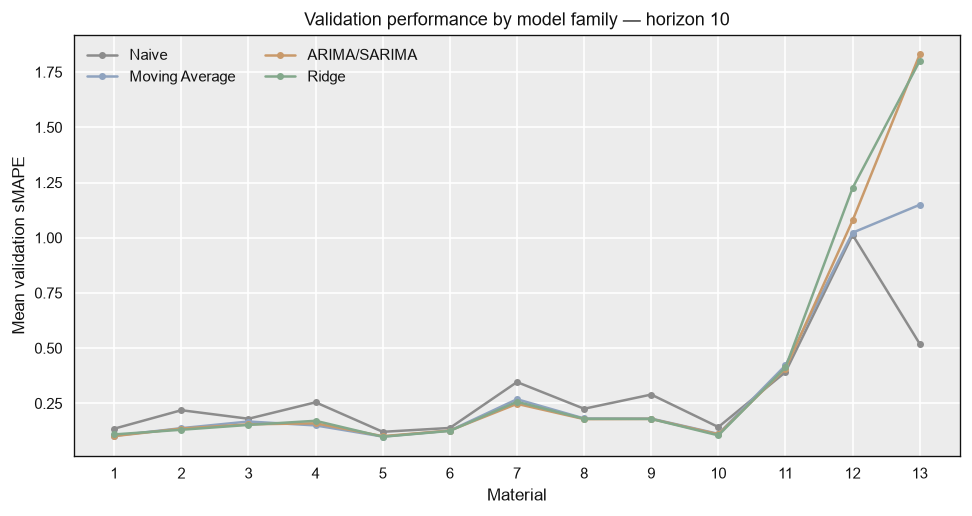

Saved: D:\TU_DataScience\22_Data Mining Cup\TS-Forecasting-Project\outputs\figures\validation_model_families_h10_linear.png


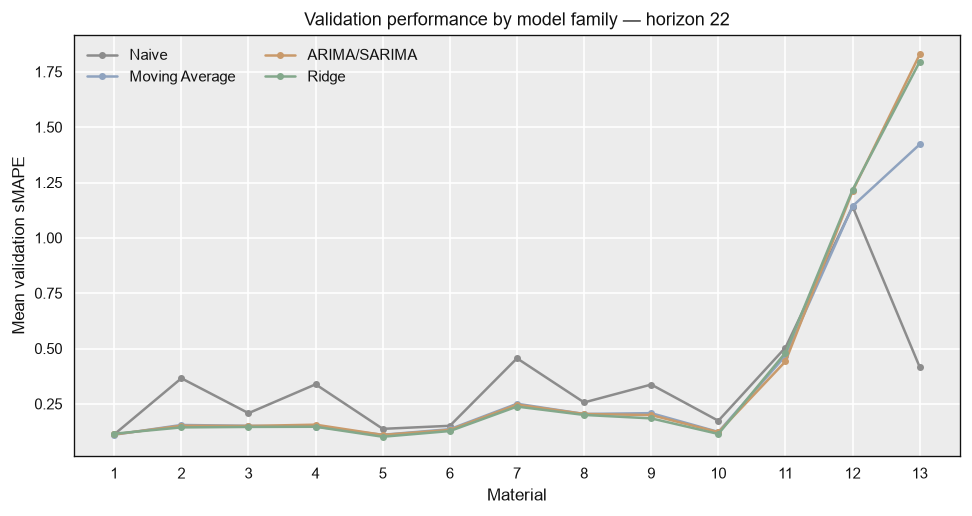

Saved: D:\TU_DataScience\22_Data Mining Cup\TS-Forecasting-Project\outputs\figures\validation_model_families_h22_linear.png


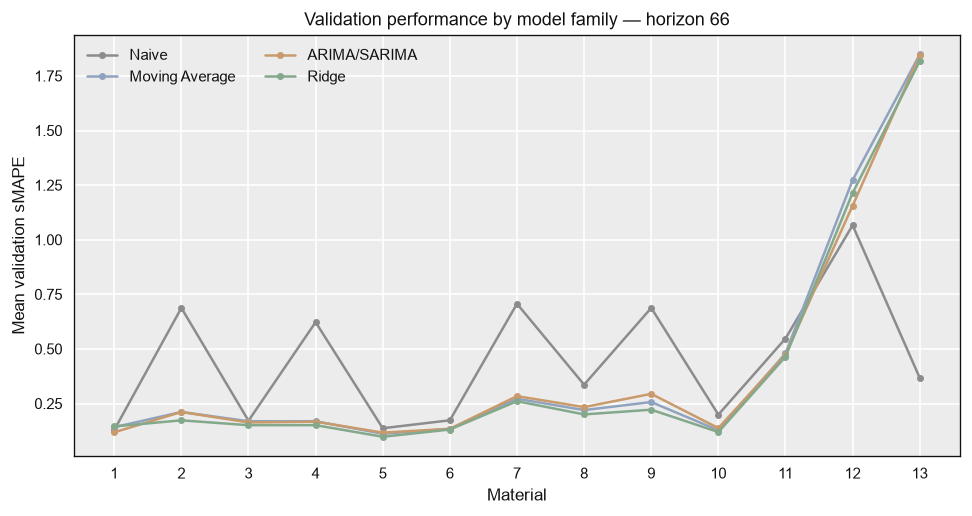

Saved: D:\TU_DataScience\22_Data Mining Cup\TS-Forecasting-Project\outputs\figures\validation_model_families_h66_linear.png


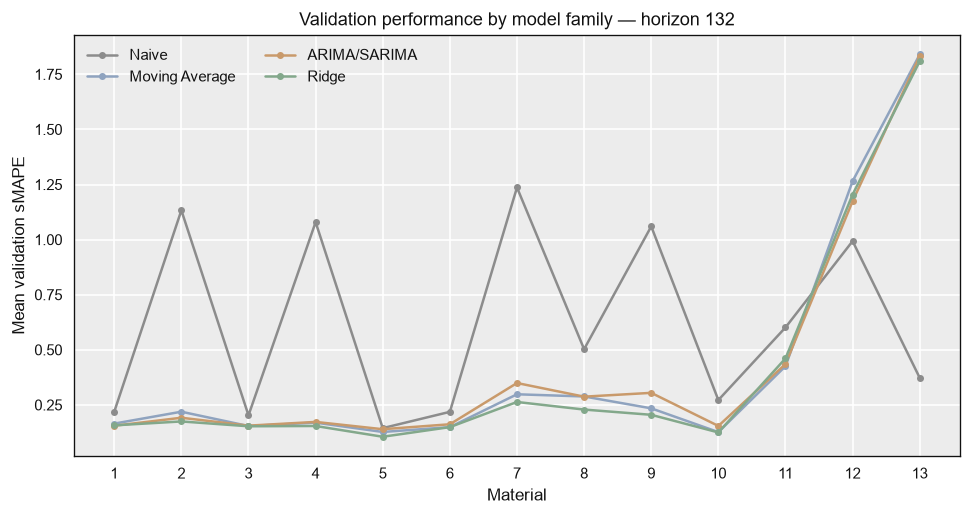

Saved: D:\TU_DataScience\22_Data Mining Cup\TS-Forecasting-Project\outputs\figures\validation_model_families_h132_linear.png


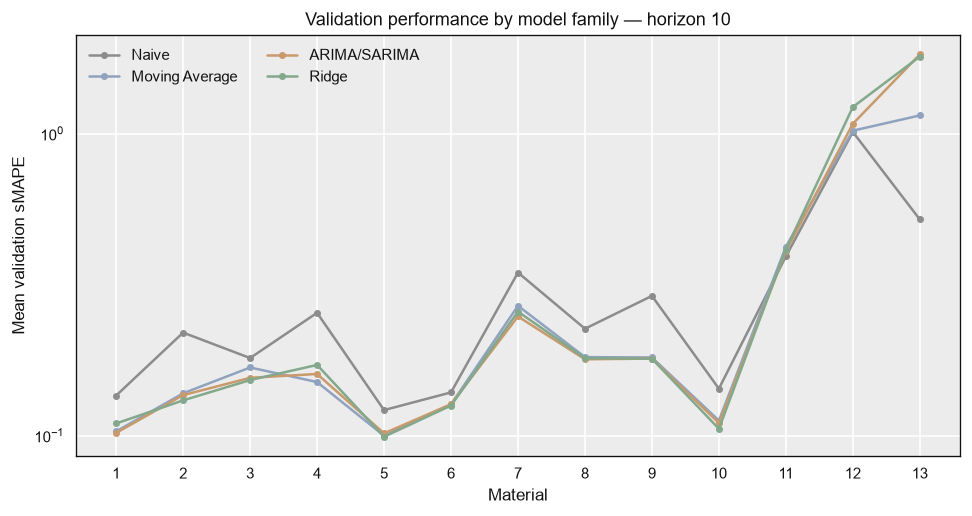

Saved: D:\TU_DataScience\22_Data Mining Cup\TS-Forecasting-Project\outputs\figures\validation_model_families_h10_log.png


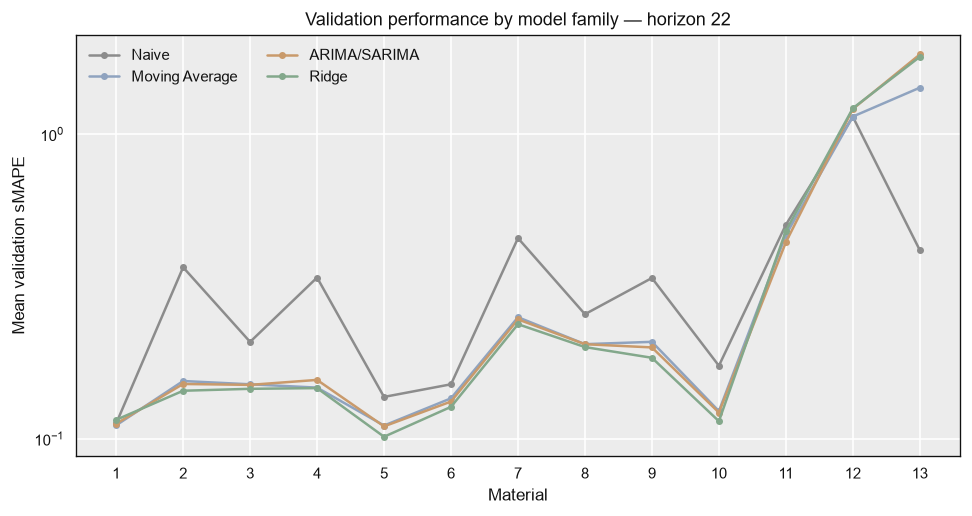

Saved: D:\TU_DataScience\22_Data Mining Cup\TS-Forecasting-Project\outputs\figures\validation_model_families_h22_log.png


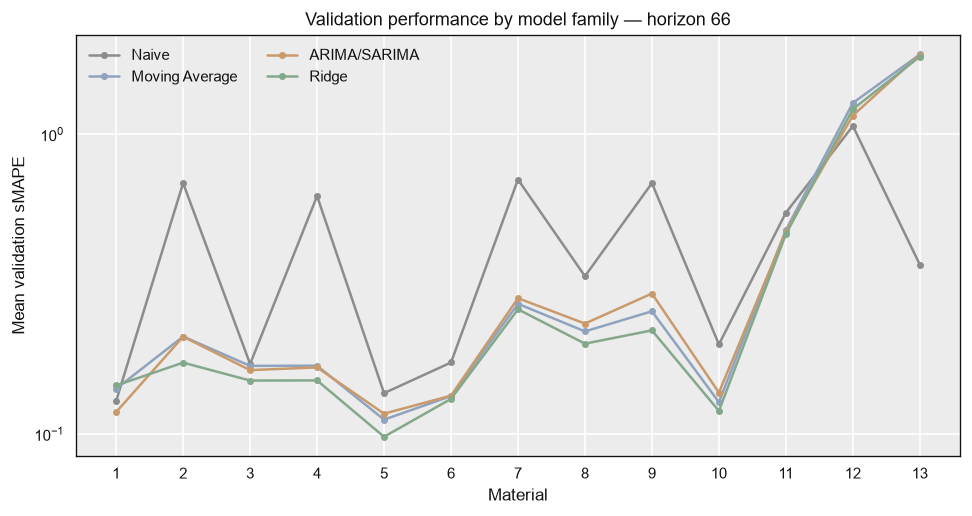

Saved: D:\TU_DataScience\22_Data Mining Cup\TS-Forecasting-Project\outputs\figures\validation_model_families_h66_log.png


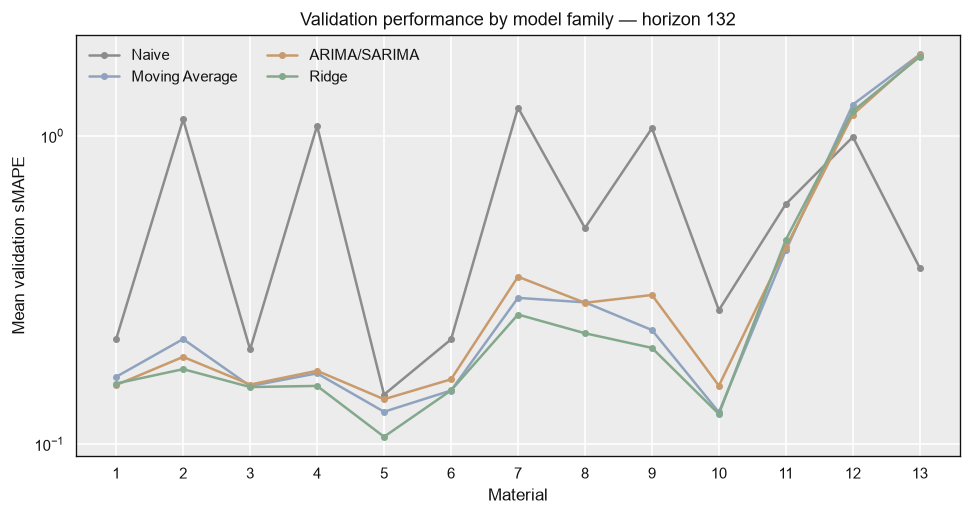

Saved: D:\TU_DataScience\22_Data Mining Cup\TS-Forecasting-Project\outputs\figures\validation_model_families_h132_log.png


In [7]:
def plot_validation_lines(horizon, log_scale=False):
    sub = (
        validation_long.loc[validation_long["horizon"] == horizon]
        .copy()
        .sort_values(["model_family", "material"])
    )

    fig, ax = plt.subplots(figsize=(8.2, 4.4))

    for family in FAMILY_ORDER:
        d = sub.loc[sub["model_family"] == family].sort_values("material")
        ax.plot(
            d["material"],
            d["mean_smape"],
            marker="o",
            markersize=4.2,
            linewidth=1.5,
            label=family,
            color=FAMILY_COLORS[family],
        )

    ax.set_xticks(MATERIALS)
    ax.set_xlabel("Material")
    ax.set_ylabel("Mean validation sMAPE")
    ax.set_title(f"Validation performance by model family — horizon {horizon}")

    if log_scale:
        ax.set_yscale("log")

    finish_axis(ax, grid_axis="both")
    ax.legend(frameon=False, ncol=2)
    fig.tight_layout()

    suffix = "log" if log_scale else "linear"
    output = FIGURE_DIR / f"validation_model_families_h{horizon}_{suffix}.png"
    fig.savefig(output, bbox_inches="tight")
    plt.show()
    print("Saved:", output)

for h in HORIZONS:
    plot_validation_lines(h, log_scale=False)

# Optional alternative that is often easier to read because Materials 12 and 13
# have much larger errors than most other materials.
for h in HORIZONS:
    plot_validation_lines(h, log_scale=True)


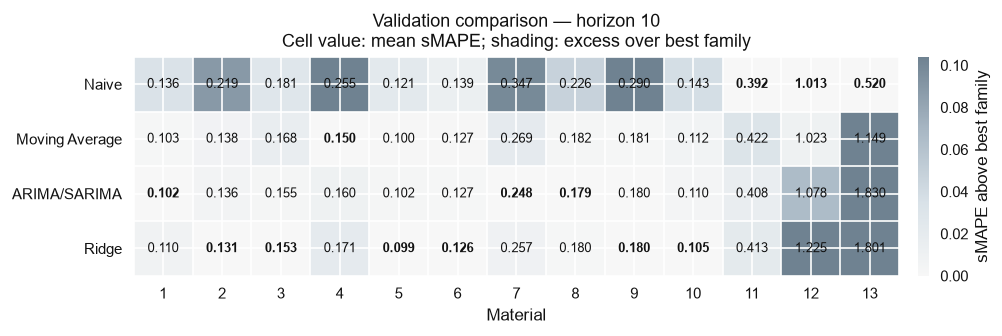

Saved: D:\TU_DataScience\22_Data Mining Cup\TS-Forecasting-Project\outputs\figures\validation_family_heatmap_h10.png


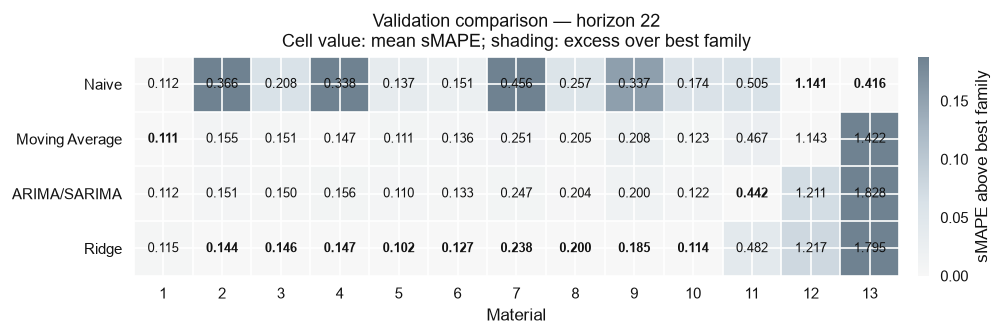

Saved: D:\TU_DataScience\22_Data Mining Cup\TS-Forecasting-Project\outputs\figures\validation_family_heatmap_h22.png


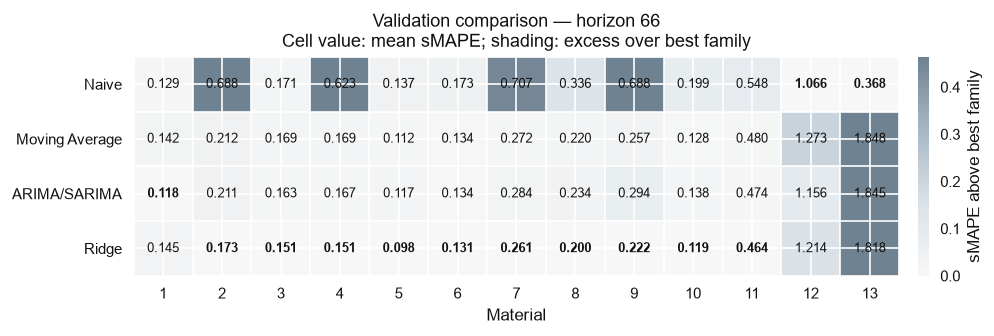

Saved: D:\TU_DataScience\22_Data Mining Cup\TS-Forecasting-Project\outputs\figures\validation_family_heatmap_h66.png


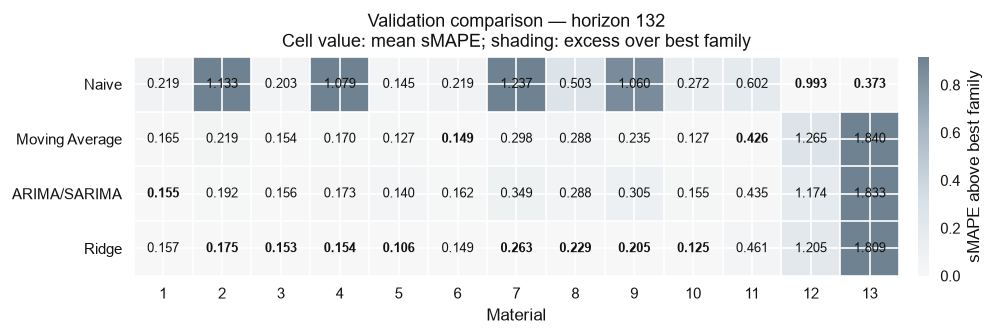

Saved: D:\TU_DataScience\22_Data Mining Cup\TS-Forecasting-Project\outputs\figures\validation_family_heatmap_h132.png


In [8]:
# Muted light-to-dark scale for "distance from best".
GAP_CMAP = LinearSegmentedColormap.from_list(
    "muted_gap",
    ["#F7F7F7", "#D9E2E8", "#A8B7C4", "#6F8291"]
)


def plot_validation_heatmap(horizon):
    sub = validation_long.loc[validation_long["horizon"] == horizon].copy()

    score_matrix = (
        sub.pivot(index="model_family", columns="material", values="mean_smape")
        .reindex(index=FAMILY_ORDER, columns=MATERIALS)
    )

    best_per_material = score_matrix.min(axis=0)
    gap_matrix = score_matrix.subtract(best_per_material, axis=1)

    # Robust upper limit keeps a few large gaps from washing out the rest.
    positive_gaps = gap_matrix.to_numpy().ravel()
    positive_gaps = positive_gaps[np.isfinite(positive_gaps)]
    vmax = np.quantile(positive_gaps, 0.90)
    if vmax <= 0:
        vmax = positive_gaps.max() if len(positive_gaps) else 1.0

    fig, ax = plt.subplots(figsize=(9.0, 2.9))
    image = ax.imshow(
        gap_matrix.values,
        aspect="auto",
        cmap=GAP_CMAP,
        vmin=0,
        vmax=vmax,
    )

    ax.set_xticks(np.arange(len(MATERIALS)))
    ax.set_xticklabels(MATERIALS)
    ax.set_yticks(np.arange(len(FAMILY_ORDER)))
    ax.set_yticklabels(FAMILY_ORDER)
    ax.set_xlabel("Material")
    ax.set_title(
        f"Validation comparison — horizon {horizon}\n"
        "Cell value: mean sMAPE; shading: excess over best family"
    )

    for i, family in enumerate(FAMILY_ORDER):
        for j, material in enumerate(MATERIALS):
            value = score_matrix.loc[family, material]
            is_best = np.isclose(
                value,
                best_per_material.loc[material],
                rtol=0,
                atol=1e-12
            )
            text = f"{value:.3f}"
            ax.text(
                j, i, text,
                ha="center",
                va="center",
                fontsize=7.5,
                fontweight="bold" if is_best else "normal",
                color=TEXT_COLOR,
            )

    # Cell borders
    ax.set_xticks(np.arange(-0.5, len(MATERIALS), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(FAMILY_ORDER), 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.0)
    ax.tick_params(which="minor", bottom=False, left=False)

    cbar = fig.colorbar(image, ax=ax, pad=0.02)
    cbar.set_label("sMAPE above best family")

    fig.tight_layout()
    output = FIGURE_DIR / f"validation_family_heatmap_h{horizon}.png"
    fig.savefig(output, bbox_inches="tight")
    plt.show()
    print("Saved:", output)


for h in HORIZONS:
    plot_validation_heatmap(h)


C:\Users\Sed\AppData\Local\Temp\ipykernel_36208\1083716445.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  numeric_matrix = selection_matrix.replace(family_to_code).astype(int)


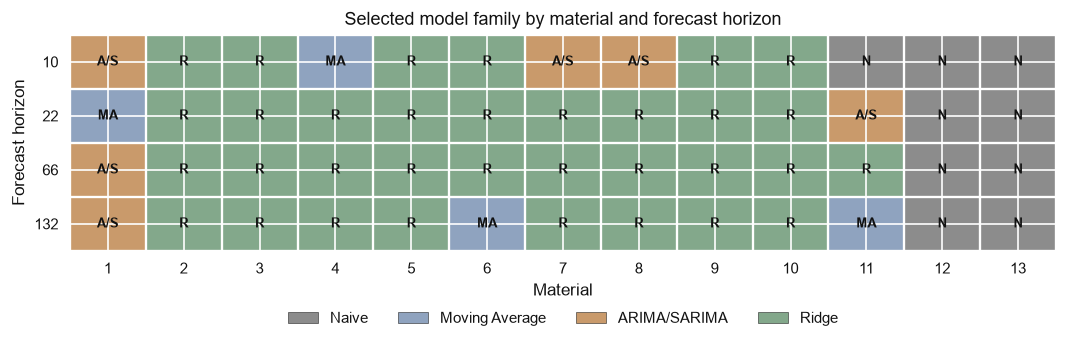

Saved: D:\TU_DataScience\22_Data Mining Cup\TS-Forecasting-Project\outputs\figures\selected_model_family_map.png


In [9]:
family_to_code = {
    "Naive": 0,
    "Moving Average": 1,
    "ARIMA/SARIMA": 2,
    "Ridge": 3,
}
code_to_short = {
    0: "N",
    1: "MA",
    2: "A/S",
    3: "R",
}

selection_matrix = (
    frozen.pivot(index="horizon", columns="material", values="model_family")
    .reindex(index=HORIZONS, columns=MATERIALS)
)

numeric_matrix = selection_matrix.replace(family_to_code).astype(int)

selection_cmap = ListedColormap(
    [FAMILY_COLORS[f] for f in FAMILY_ORDER]
)

fig, ax = plt.subplots(figsize=(9.0, 3.1))
ax.imshow(
    numeric_matrix.values,
    aspect="auto",
    cmap=selection_cmap,
    vmin=-0.5,
    vmax=3.5,
)

ax.set_xticks(np.arange(len(MATERIALS)))
ax.set_xticklabels(MATERIALS)
ax.set_yticks(np.arange(len(HORIZONS)))
ax.set_yticklabels(HORIZONS)

ax.set_xlabel("Material")
ax.set_ylabel("Forecast horizon")
ax.set_title("Selected model family by material and forecast horizon")

for i in range(len(HORIZONS)):
    for j in range(len(MATERIALS)):
        code = int(numeric_matrix.iloc[i, j])
        ax.text(
            j, i,
            code_to_short[code],
            ha="center",
            va="center",
            fontsize=8,
            fontweight="bold",
            color=TEXT_COLOR,
        )

ax.set_xticks(np.arange(-0.5, len(MATERIALS), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(HORIZONS), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=1.4)
ax.tick_params(which="minor", bottom=False, left=False)

legend_handles = [
    Patch(facecolor=FAMILY_COLORS[f], edgecolor=TEXT_COLOR, label=f)
    for f in FAMILY_ORDER
]
ax.legend(
    handles=legend_handles,
    frameon=False,
    ncol=4,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.22),
)

fig.tight_layout()
output = FIGURE_DIR / "selected_model_family_map.png"
fig.savefig(output, bbox_inches="tight")
plt.show()
print("Saved:", output)


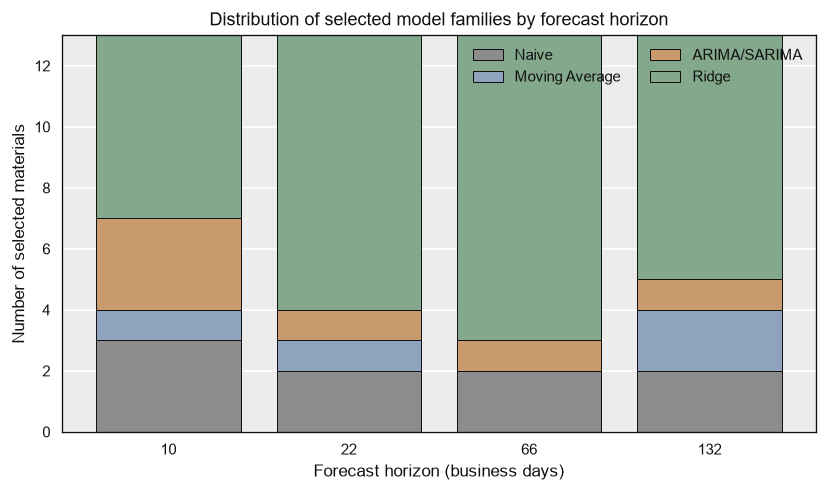

Saved: D:\TU_DataScience\22_Data Mining Cup\TS-Forecasting-Project\outputs\figures\selected_model_family_counts.png


In [10]:
count_plot = family_counts.rename(columns={
    "naive_count": "Naive",
    "moving_average_count": "Moving Average",
    "arima_sarima_count": "ARIMA/SARIMA",
    "ridge_count": "Ridge",
}).copy()

fig, ax = plt.subplots(figsize=(7.0, 4.2))

bottom = np.zeros(len(count_plot))
x = np.arange(len(count_plot))

for family in FAMILY_ORDER:
    values = count_plot[family].to_numpy()
    ax.bar(
        x,
        values,
        bottom=bottom,
        label=family,
        color=FAMILY_COLORS[family],
        edgecolor=TEXT_COLOR,
        linewidth=0.6,
    )
    bottom += values

ax.set_xticks(x)
ax.set_xticklabels(count_plot["horizon"].astype(str))
ax.set_xlabel("Forecast horizon (business days)")
ax.set_ylabel("Number of selected materials")
ax.set_title("Distribution of selected model families by forecast horizon")
ax.set_ylim(0, 13)

finish_axis(ax, grid_axis="y")
ax.legend(frameon=False, ncol=2)

fig.tight_layout()
output = FIGURE_DIR / "selected_model_family_counts.png"
fig.savefig(output, bbox_inches="tight")
plt.show()
print("Saved:", output)


,horizon,n_selected_ridge,day_of_week,public_holiday,school_holiday,input_features
0,10,6,2,0,2,5
1,22,9,2,1,5,3
2,66,10,2,2,5,5
3,132,8,2,1,3,0


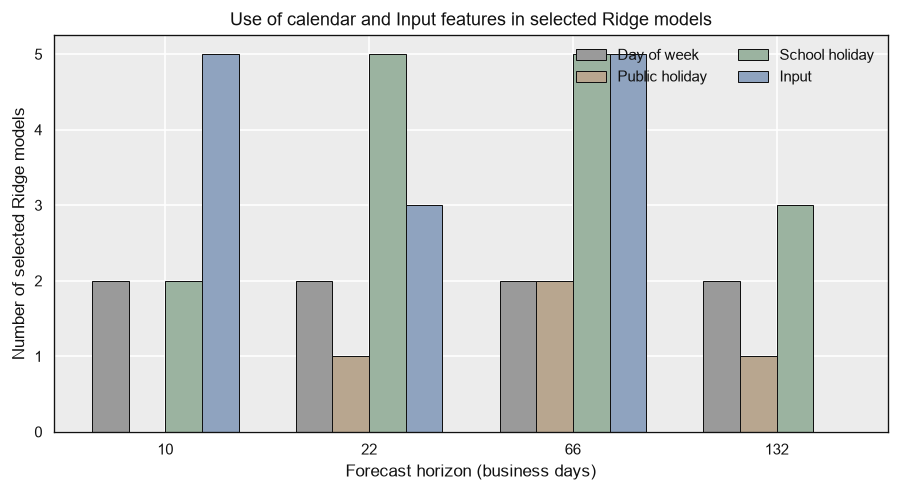

Saved: D:\TU_DataScience\22_Data Mining Cup\TS-Forecasting-Project\outputs\figures\ridge_selected_feature_counts.png


In [11]:
ridge = frozen.loc[frozen["model_family"] == "Ridge"].copy()

ridge["uses_input"] = (
        ridge["input_lags"].notna() | ridge["input_rolling"].notna()
).astype(int)

feature_counts = (
    ridge.groupby("horizon", as_index=False)
    .agg(
        n_selected_ridge=("material", "size"),
        day_of_week=("use_day_of_week", "sum"),
        public_holiday=("use_public_holiday", "sum"),
        school_holiday=("use_school_holiday", "sum"),
        input_features=("uses_input", "sum"),
    )
)

# Make integer columns explicit.
for col in [
    "n_selected_ridge",
    "day_of_week",
    "public_holiday",
    "school_holiday",
    "input_features",
]:
    feature_counts[col] = feature_counts[col].astype(int)

display(feature_counts)

feature_counts.to_csv(
    TABLE_DIR / "ridge_feature_selection_counts.csv",
    index=False
)

feature_labels = {
    "day_of_week": "Day of week",
    "public_holiday": "Public holiday",
    "school_holiday": "School holiday",
    "input_features": "Input",
}

feature_colors = {
    "day_of_week": "#9A9A9A",
    "public_holiday": "#B8A68F",
    "school_holiday": "#9BB3A0",
    "input_features": "#8FA3BF",
}

fig, ax = plt.subplots(figsize=(7.6, 4.2))

x = np.arange(len(HORIZONS))
width = 0.18
offsets = np.array([-1.5, -0.5, 0.5, 1.5]) * width

for offset, feature in zip(offsets, feature_labels):
    ax.bar(
        x + offset,
        feature_counts.set_index("horizon").loc[HORIZONS, feature].values,
        width=width,
        label=feature_labels[feature],
        color=feature_colors[feature],
        edgecolor=TEXT_COLOR,
        linewidth=0.6,
    )

ax.set_xticks(x)
ax.set_xticklabels(HORIZONS)
ax.set_xlabel("Forecast horizon (business days)")
ax.set_ylabel("Number of selected Ridge models")
ax.set_title("Use of calendar and Input features in selected Ridge models")

finish_axis(ax, grid_axis="y")
ax.legend(frameon=False, ncol=2)

fig.tight_layout()
output = FIGURE_DIR / "ridge_selected_feature_counts.png"
fig.savefig(output, bbox_inches="tight")
plt.show()
print("Saved:", output)


In [13]:
# ------------------------------------------------------------
# Table A: selected model-family counts
# ------------------------------------------------------------
model_family_table = family_counts.rename(columns={
    "horizon": "Horizon",
    "n_validation_folds": "Validation folds",
    "naive_count": "Naive",
    "moving_average_count": "Moving Average",
    "arima_sarima_count": "ARIMA/SARIMA",
    "ridge_count": "Ridge",
})

display(model_family_table)

model_family_table.to_csv(
    TABLE_DIR / "selected_model_family_counts_report.csv",
    index=False
)

print(
    model_family_table.to_latex(
        index=False,
        escape=False,
        float_format="%.3f"
    )
)


,Horizon,Validation folds,Naive,Moving Average,ARIMA/SARIMA,Ridge
0,10,27,3,1,3,6
1,22,12,2,1,1,9
2,66,4,2,0,1,10
3,132,2,2,2,1,8


\begin{tabular}{rrrrrr}
\toprule
Horizon & Validation folds & Naive & Moving Average & ARIMA/SARIMA & Ridge \\
\midrule
10 & 27 & 3 & 1 & 3 & 6 \\
22 & 12 & 2 & 1 & 1 & 9 \\
66 & 4 & 2 & 0 & 1 & 10 \\
132 & 2 & 2 & 2 & 1 & 8 \\
\bottomrule
\end{tabular}



In [14]:
# ------------------------------------------------------------
# Table B: selected model for each material and horizon
# ------------------------------------------------------------
selected_family_matrix = (
    frozen.pivot(
        index="material",
        columns="horizon",
        values="model_family"
    )
    .reindex(index=MATERIALS, columns=HORIZONS)
)

selected_family_matrix.index.name = "Material"
selected_family_matrix.columns = [f"H{h}" for h in selected_family_matrix.columns]

display(selected_family_matrix)

selected_family_matrix.to_csv(
    TABLE_DIR / "selected_model_family_matrix.csv"
)


,H10,H22,H66,H132
Material,,,,
1,ARIMA/SARIMA,Moving Average,ARIMA/SARIMA,ARIMA/SARIMA
2,Ridge,Ridge,Ridge,Ridge
3,Ridge,Ridge,Ridge,Ridge
4,Moving Average,Ridge,Ridge,Ridge
5,Ridge,Ridge,Ridge,Ridge
6,Ridge,Ridge,Ridge,Moving Average
7,ARIMA/SARIMA,Ridge,Ridge,Ridge
8,ARIMA/SARIMA,Ridge,Ridge,Ridge
9,Ridge,Ridge,Ridge,Ridge


In [15]:
# ------------------------------------------------------------
# Table C: cases where the frozen model was not the absolute minimum
# validation sMAPE among the four family representatives.
# These are useful for documenting the "prefer simpler if practically tied"
# rule from Section 3.6.
# ------------------------------------------------------------
near_ties = (
    validation_wide.loc[
        validation_wide["frozen_matches_minimum_smape"] == 0,
        [
            "horizon",
            "material",
            "best_family_by_mean_smape",
            "best_family_mean_smape",
            "frozen_model_family",
            "frozen_model_name",
            "frozen_validation_mean_smape",
            "frozen_minus_best_smape",
        ]
    ]
    .sort_values(["horizon", "material"])
)

display(near_ties)

near_ties.to_csv(
    TABLE_DIR / "frozen_model_near_ties.csv",
    index=False
)


,horizon,material,best_family_by_mean_smape,best_family_mean_smape,frozen_model_family,frozen_model_name,frozen_validation_mean_smape,frozen_minus_best_smape
6,10,7,ARIMA/SARIMA,0.248034,ARIMA/SARIMA,arima_011,0.248142,0.000107
32,66,7,Ridge,0.260733,Ridge,ridge_h66_m7_roll66_alpha_0.0001_holiday,0.260885,0.000152
34,66,9,Ridge,0.221791,Ridge,ridge_h66_m9_no_roll_alpha_0.0001_schoolholiday,0.222079,0.000288


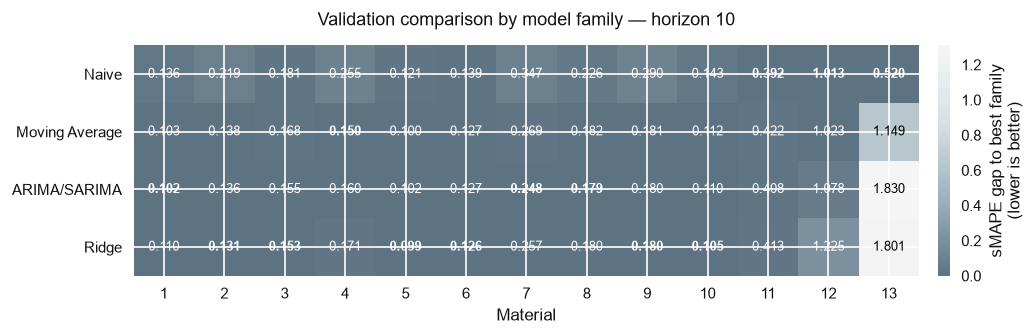

Saved: D:\TU_DataScience\22_Data Mining Cup\TS-Forecasting-Project\outputs\figures\validation_family_heatmap_clean_h10.png


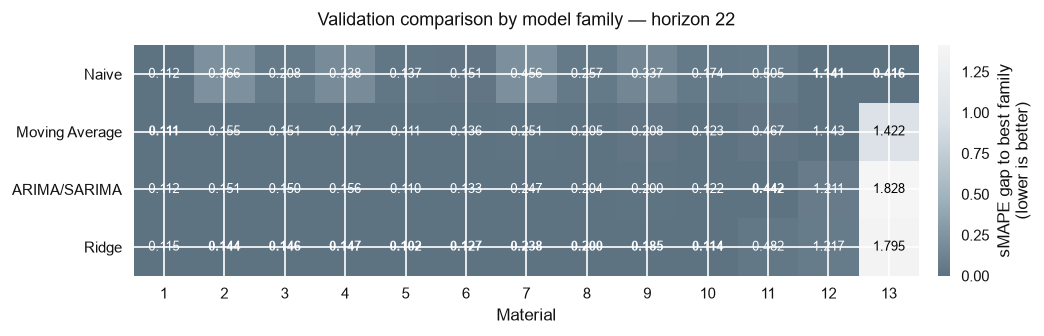

Saved: D:\TU_DataScience\22_Data Mining Cup\TS-Forecasting-Project\outputs\figures\validation_family_heatmap_clean_h22.png


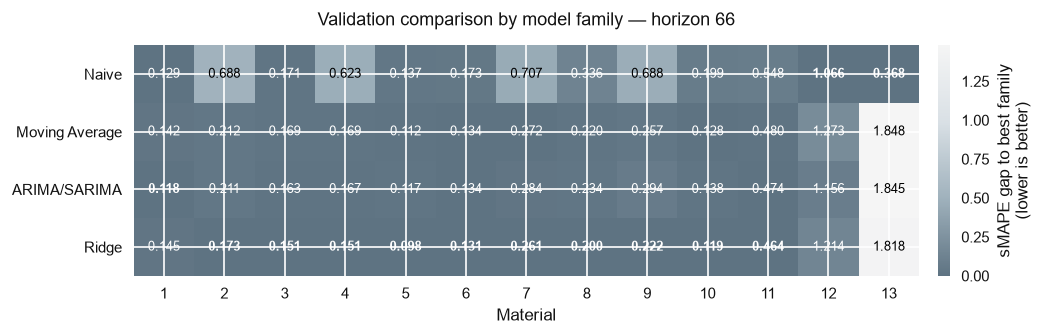

Saved: D:\TU_DataScience\22_Data Mining Cup\TS-Forecasting-Project\outputs\figures\validation_family_heatmap_clean_h66.png


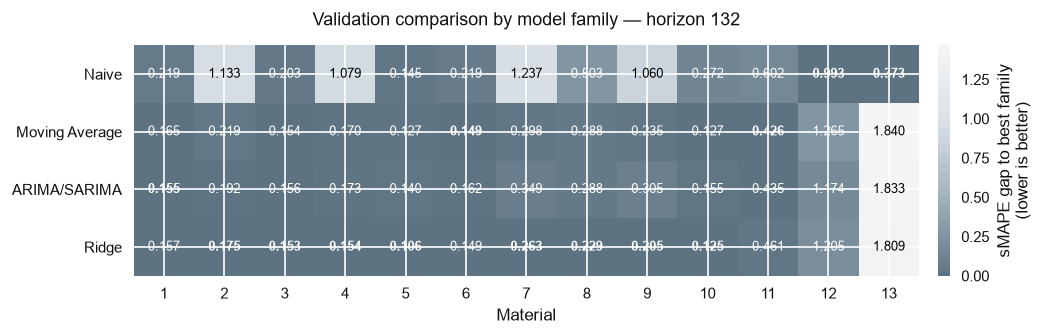

Saved: D:\TU_DataScience\22_Data Mining Cup\TS-Forecasting-Project\outputs\figures\validation_family_heatmap_clean_h132.png


In [16]:
# ------------------------------------------------------------
# Improved validation heatmaps
# darker = better (lower sMAPE gap to best family)
# no inner grid lines
# ------------------------------------------------------------
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import matplotlib.pyplot as plt

HEATMAP_CMAP = LinearSegmentedColormap.from_list(
    "better_dark",
    ["#5E7382", "#9FB1BC", "#D9E0E5", "#F5F5F5"]
)
# left = dark, right = light
# darker means smaller gap to the best family

def plot_validation_heatmap_clean(horizon):
    sub = validation_long.loc[validation_long["horizon"] == horizon].copy()

    score_matrix = (
        sub.pivot(index="model_family", columns="material", values="mean_smape")
        .reindex(index=FAMILY_ORDER, columns=MATERIALS)
    )

    best_per_material = score_matrix.min(axis=0)
    gap_matrix = score_matrix.subtract(best_per_material, axis=1)

    vmax = gap_matrix.to_numpy().max()
    if vmax <= 0:
        vmax = 1.0

    fig, ax = plt.subplots(figsize=(9.2, 2.9))

    im = ax.imshow(
        gap_matrix.values,
        aspect="auto",
        cmap=HEATMAP_CMAP,
        vmin=0,
        vmax=vmax
    )

    ax.set_xticks(np.arange(len(MATERIALS)))
    ax.set_xticklabels(MATERIALS)
    ax.set_yticks(np.arange(len(FAMILY_ORDER)))
    ax.set_yticklabels(FAMILY_ORDER)

    ax.set_xlabel("Material")
    ax.set_title(
        f"Validation comparison by model family — horizon {horizon}",
        pad=12
    )

    # remove spines
    for spine in ax.spines.values():
        spine.set_visible(False)

    # annotate actual mean sMAPE values
    for i, family in enumerate(FAMILY_ORDER):
        for j, material in enumerate(MATERIALS):
            value = score_matrix.loc[family, material]
            gap = gap_matrix.loc[family, material]
            is_best = np.isclose(gap, 0.0, atol=1e-12)

            # darker cells need white text
            text_color = "white" if gap <= 0.30 * vmax else "black"

            ax.text(
                j, i,
                f"{value:.3f}",
                ha="center",
                va="center",
                fontsize=8,
                fontweight="bold" if is_best else "normal",
                color=text_color
            )

    cbar = fig.colorbar(im, ax=ax, pad=0.02)
    cbar.set_label("sMAPE gap to best family\n(lower is better)")
    cbar.outline.set_visible(False)

    fig.tight_layout()
    output = FIGURE_DIR / f"validation_family_heatmap_clean_h{horizon}.png"
    fig.savefig(output, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", output)

for h in HORIZONS:
    plot_validation_heatmap_clean(h)

,horizon,n_selected_ridge,day_of_week,public_holiday,school_holiday,input_features
0,10,6,2.0,0.0,2.0,5
1,22,9,2.0,1.0,5.0,3
2,66,10,2.0,2.0,5.0,5
3,132,8,2.0,1.0,3.0,0


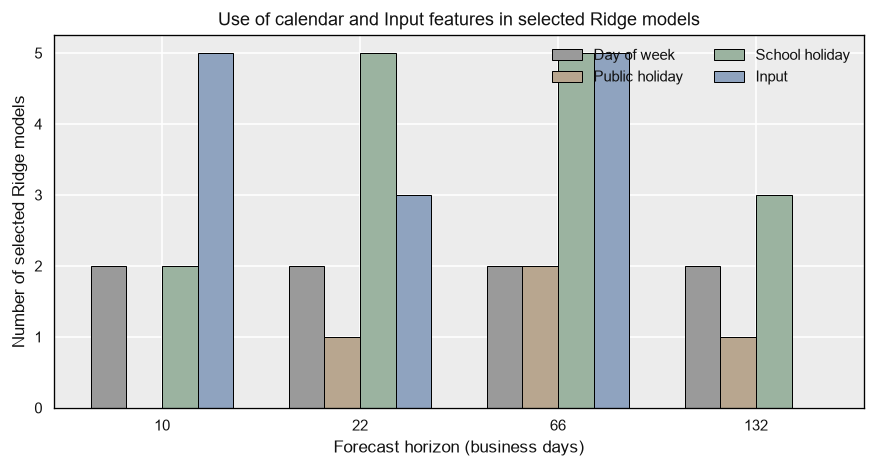

Saved: D:\TU_DataScience\22_Data Mining Cup\TS-Forecasting-Project\outputs\figures\ridge_selected_feature_counts_clean.png


In [17]:
# ------------------------------------------------------------
# Cleaner Ridge feature usage plot
# ------------------------------------------------------------
ridge = frozen.loc[frozen["model_family"] == "Ridge"].copy()

ridge["uses_input"] = (
    ridge["input_lags"].fillna("").astype(str).str.strip().ne("") |
    ridge["input_rolling"].fillna("").astype(str).str.strip().ne("")
).astype(int)

feature_counts = (
    ridge.groupby("horizon", as_index=False)
    .agg(
        n_selected_ridge=("material", "size"),
        day_of_week=("use_day_of_week", "sum"),
        public_holiday=("use_public_holiday", "sum"),
        school_holiday=("use_school_holiday", "sum"),
        input_features=("uses_input", "sum"),
    )
)

display(feature_counts)

feature_counts.to_csv(
    TABLE_DIR / "ridge_feature_selection_counts.csv",
    index=False
)

feature_labels = {
    "day_of_week": "Day of week",
    "public_holiday": "Public holiday",
    "school_holiday": "School holiday",
    "input_features": "Input",
}

feature_colors = {
    "day_of_week": "#9A9A9A",
    "public_holiday": "#B8A68F",
    "school_holiday": "#9BB3A0",
    "input_features": "#8FA3BF",
}

fig, ax = plt.subplots(figsize=(7.4, 4.0))

x = np.arange(len(HORIZONS))
width = 0.18
offsets = np.array([-1.5, -0.5, 0.5, 1.5]) * width

for offset, feature in zip(offsets, feature_labels):
    ax.bar(
        x + offset,
        feature_counts.set_index("horizon").loc[HORIZONS, feature].values,
        width=width,
        label=feature_labels[feature],
        color=feature_colors[feature],
        edgecolor="black",
        linewidth=0.6,
    )

ax.set_xticks(x)
ax.set_xticklabels(HORIZONS)
ax.set_xlabel("Forecast horizon (business days)")
ax.set_ylabel("Number of selected Ridge models")
ax.set_title("Use of calendar and Input features in selected Ridge models")

ax.grid(True, axis="y", color="white", linewidth=1.0)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(0.8)

ax.legend(frameon=False, ncol=2, loc="upper right")

fig.tight_layout()
output = FIGURE_DIR / "ridge_selected_feature_counts_clean.png"
fig.savefig(output, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", output)

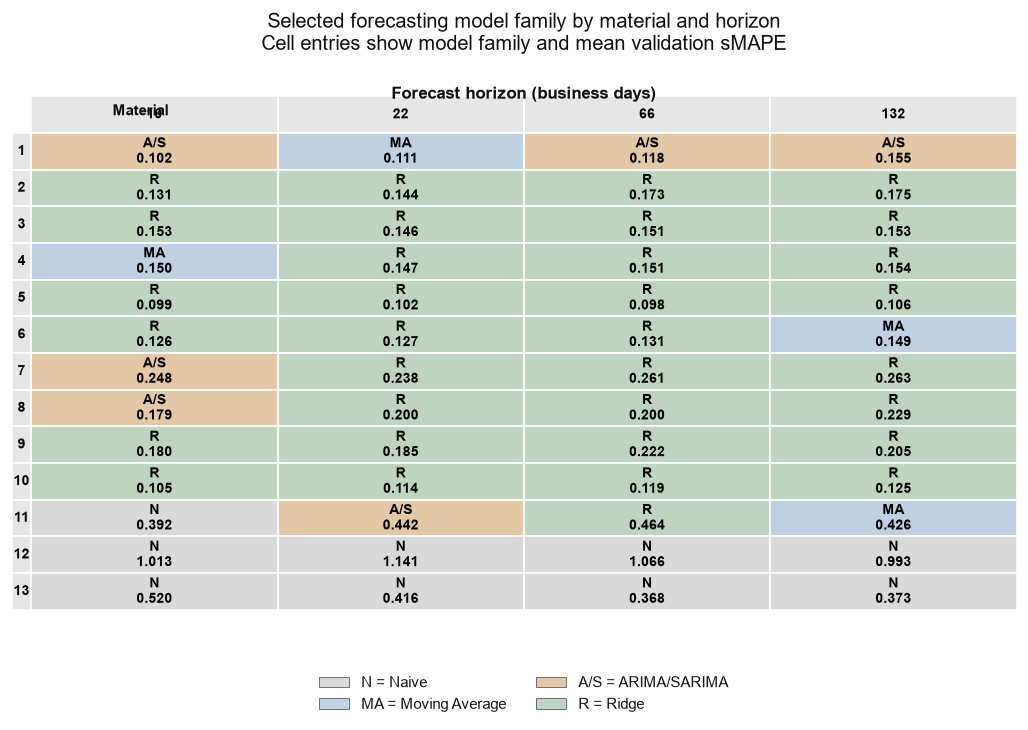

Saved: D:\TU_DataScience\22_Data Mining Cup\TS-Forecasting-Project\outputs\figures\selected_model_family_table.png


In [18]:
# ------------------------------------------------------------
# Table figure: selected model family by material and horizon
# ------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

family_abbrev = {
    "Naive": "N",
    "Moving Average": "MA",
    "ARIMA/SARIMA": "A/S",
    "Ridge": "R",
}

family_colors = {
    "Naive": "#D9D9D9",
    "Moving Average": "#BFD0E3",
    "ARIMA/SARIMA": "#E3C7A6",
    "Ridge": "#BFD3C1",
}

# Build display table from frozen configurations
table_df = frozen.copy()

table_df["cell_text"] = (
    table_df["model_family"].map(family_abbrev)
    + "\n"
    + table_df["validation_mean_smape"].map(lambda x: f"{x:.3f}")
)

display_table = (
    table_df.pivot(index="material", columns="horizon", values="cell_text")
    .reindex(index=MATERIALS, columns=HORIZONS)
)

display_family = (
    table_df.pivot(index="material", columns="horizon", values="model_family")
    .reindex(index=MATERIALS, columns=HORIZONS)
)

# Save a CSV version too
selected_table_csv = (
    table_df[["material", "horizon", "model_family", "model_name", "validation_mean_smape"]]
    .sort_values(["material", "horizon"])
)
selected_table_csv.to_csv(
    TABLE_DIR / "selected_models_table.csv",
    index=False
)

fig, ax = plt.subplots(figsize=(8.6, 6.2))
ax.axis("off")

tbl = ax.table(
    cellText=display_table.values,
    rowLabels=[str(m) for m in display_table.index],
    colLabels=[str(h) for h in display_table.columns],
    cellLoc="center",
    rowLoc="center",
    loc="center"
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1.15, 1.9)

# Header styling
for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor("white")
    cell.set_linewidth(1.0)

    # Column headers
    if row == 0:
        cell.set_facecolor("#E6E6E6")
        cell.set_text_props(weight="bold", color="black")

    # Row labels
    if col == -1 and row > 0:
        cell.set_facecolor("#E6E6E6")
        cell.set_text_props(weight="bold", color="black")

# Data cells
for i, material in enumerate(display_table.index, start=1):
    for j, horizon in enumerate(display_table.columns):
        family = display_family.loc[material, horizon]
        cell = tbl[(i, j)]
        cell.set_facecolor(family_colors[family])
        cell.set_text_props(weight="bold", color="black")

ax.set_title(
    "Selected forecasting model family by material and horizon\n"
    "Cell entries show model family and mean validation sMAPE",
    fontsize=12,
    pad=16
)

# Add top-left label manually
ax.text(
    0.02, 0.93,
    "Material",
    transform=ax.transAxes,
    fontsize=9,
    fontweight="bold"
)

ax.text(
    0.50, 0.96,
    "Forecast horizon (business days)",
    transform=ax.transAxes,
    ha="center",
    fontsize=10,
    fontweight="bold"
)

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor=family_colors["Naive"], edgecolor="black", label="N = Naive"),
    plt.Rectangle((0, 0), 1, 1, facecolor=family_colors["Moving Average"], edgecolor="black", label="MA = Moving Average"),
    plt.Rectangle((0, 0), 1, 1, facecolor=family_colors["ARIMA/SARIMA"], edgecolor="black", label="A/S = ARIMA/SARIMA"),
    plt.Rectangle((0, 0), 1, 1, facecolor=family_colors["Ridge"], edgecolor="black", label="R = Ridge"),
]

ax.legend(
    handles=legend_handles,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.06),
    ncol=2
)

fig.tight_layout()
output = FIGURE_DIR / "selected_model_family_table.png"
fig.savefig(output, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", output)

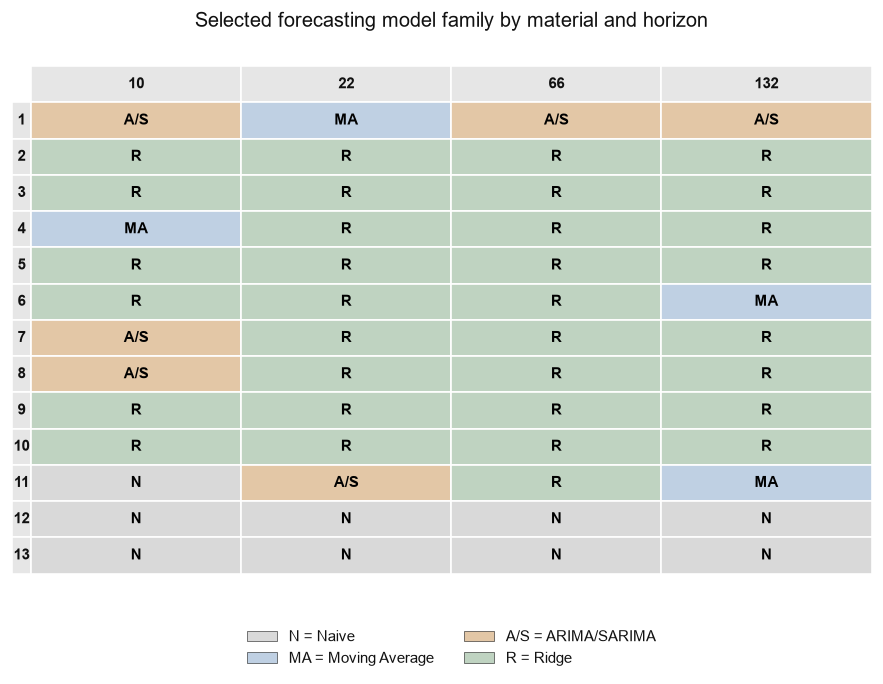

Saved: D:\TU_DataScience\22_Data Mining Cup\TS-Forecasting-Project\outputs\figures\selected_model_family_table_simple.png


In [20]:
# ------------------------------------------------------------
# Simpler table: only selected model family
# ------------------------------------------------------------
simple_display = (
    table_df.assign(label=table_df["model_family"].map(family_abbrev))
    .pivot(index="material", columns="horizon", values="label")
    .reindex(index=MATERIALS, columns=HORIZONS)
)

simple_family = (
    table_df.pivot(index="material", columns="horizon", values="model_family")
    .reindex(index=MATERIALS, columns=HORIZONS)
)

fig, ax = plt.subplots(figsize=(7.4, 5.8))
ax.axis("off")

tbl = ax.table(
    cellText=simple_display.values,
    rowLabels=[str(m) for m in simple_display.index],
    colLabels=[str(h) for h in simple_display.columns],
    cellLoc="center",
    rowLoc="center",
    loc="center"
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.1, 1.8)

for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor("white")
    cell.set_linewidth(1.0)

    if row == 0:
        cell.set_facecolor("#E6E6E6")
        cell.set_text_props(weight="bold")

    if col == -1 and row > 0:
        cell.set_facecolor("#E6E6E6")
        cell.set_text_props(weight="bold")

for i, material in enumerate(simple_display.index, start=1):
    for j, horizon in enumerate(simple_display.columns):
        family = simple_family.loc[material, horizon]
        cell = tbl[(i, j)]
        cell.set_facecolor(family_colors[family])
        cell.set_text_props(weight="bold", color="black")

ax.set_title(
    "Selected forecasting model family by material and horizon",
    fontsize=12,
    pad=14
)

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor=family_colors["Naive"], edgecolor="black", label="N = Naive"),
    plt.Rectangle((0, 0), 1, 1, facecolor=family_colors["Moving Average"], edgecolor="black", label="MA = Moving Average"),
    plt.Rectangle((0, 0), 1, 1, facecolor=family_colors["ARIMA/SARIMA"], edgecolor="black", label="A/S = ARIMA/SARIMA"),
    plt.Rectangle((0, 0), 1, 1, facecolor=family_colors["Ridge"], edgecolor="black", label="R = Ridge"),
]

ax.legend(
    handles=legend_handles,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=2
)

fig.tight_layout()
output = FIGURE_DIR / "selected_model_family_table_simple.png"
fig.savefig(output, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", output)

,horizon,n_selected_ridge,day_of_week,public_holiday,school_holiday,input_features
0,10,6,2,0,2,5
1,22,9,2,1,5,3
2,66,10,2,2,5,5
3,132,8,2,1,3,0


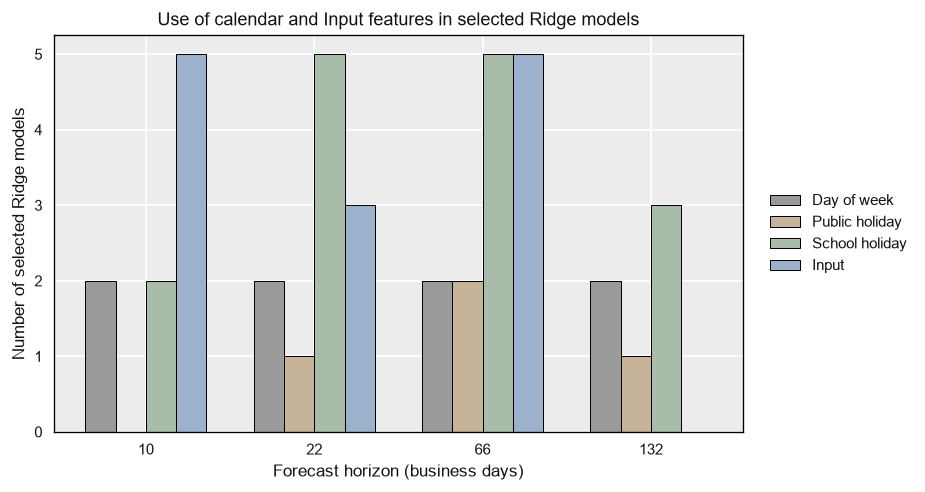

Saved: D:\TU_DataScience\22_Data Mining Cup\TS-Forecasting-Project\outputs\figures\ridge_selected_feature_counts_right_legend.png


In [19]:
# ------------------------------------------------------------
# Cleaner Ridge feature usage plot
# legend on the right, vertical
# muted colors
# ------------------------------------------------------------
ridge = frozen.loc[frozen["model_family"] == "Ridge"].copy()

ridge["uses_input"] = (
    ridge["input_lags"].fillna("").astype(str).str.strip().ne("") |
    ridge["input_rolling"].fillna("").astype(str).str.strip().ne("")
).astype(int)

feature_counts = (
    ridge.groupby("horizon", as_index=False)
    .agg(
        n_selected_ridge=("material", "size"),
        day_of_week=("use_day_of_week", "sum"),
        public_holiday=("use_public_holiday", "sum"),
        school_holiday=("use_school_holiday", "sum"),
        input_features=("uses_input", "sum"),
    )
)

for col in [
    "n_selected_ridge",
    "day_of_week",
    "public_holiday",
    "school_holiday",
    "input_features",
]:
    feature_counts[col] = feature_counts[col].astype(int)

display(feature_counts)

feature_counts.to_csv(
    TABLE_DIR / "ridge_feature_selection_counts.csv",
    index=False
)

feature_labels = {
    "day_of_week": "Day of week",
    "public_holiday": "Public holiday",
    "school_holiday": "School holiday",
    "input_features": "Input",
}

# Muted palette, softer like your other plots
feature_colors = {
    "day_of_week": "#9A9A9A",
    "public_holiday": "#C7B39A",
    "school_holiday": "#A8BCA9",
    "input_features": "#9CB2CC",
}

fig, ax = plt.subplots(figsize=(7.8, 4.2))

x = np.arange(len(HORIZONS))
width = 0.18
offsets = np.array([-1.5, -0.5, 0.5, 1.5]) * width

for offset, feature in zip(offsets, feature_labels):
    ax.bar(
        x + offset,
        feature_counts.set_index("horizon").loc[HORIZONS, feature].values,
        width=width,
        label=feature_labels[feature],
        color=feature_colors[feature],
        edgecolor="black",
        linewidth=0.6,
    )

ax.set_xticks(x)
ax.set_xticklabels(HORIZONS)
ax.set_xlabel("Forecast horizon (business days)")
ax.set_ylabel("Number of selected Ridge models")
ax.set_title("Use of calendar and Input features in selected Ridge models")

ax.grid(True, axis="y", color="white", linewidth=1.0)
ax.set_axisbelow(True)

ax.set_facecolor("#ECECEC")
fig.patch.set_facecolor("white")

for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(0.8)

ax.legend(
    frameon=False,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    ncol=1
)

plt.subplots_adjust(right=0.80)
fig.tight_layout()

output = FIGURE_DIR / "ridge_selected_feature_counts_right_legend.png"
fig.savefig(output, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", output)

C:\Users\Sed\AppData\Local\Temp\ipykernel_36208\1385246386.py:51: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  cell_text = table_data.applymap(lambda x: f"{x:.3f}")


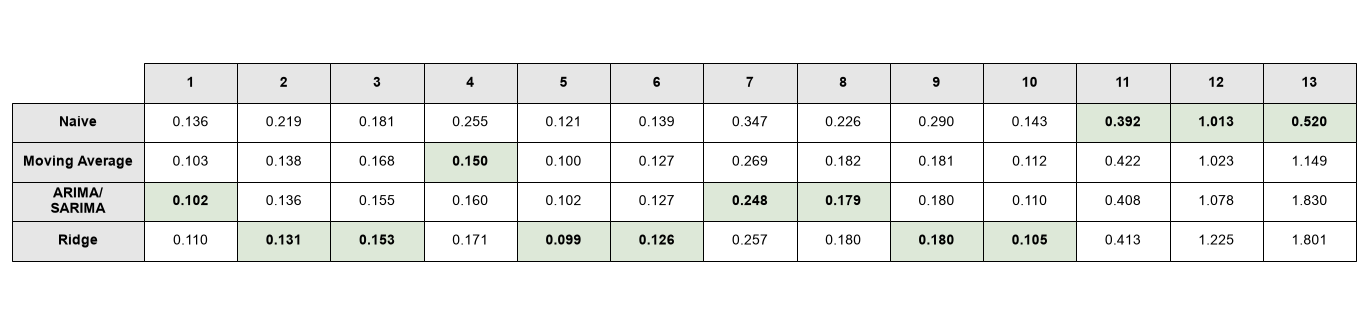

Saved: D:\TU_DataScience\22_Data Mining Cup\TS-Forecasting-Project\outputs\figures\validation_table_h10.png


C:\Users\Sed\AppData\Local\Temp\ipykernel_36208\1385246386.py:51: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  cell_text = table_data.applymap(lambda x: f"{x:.3f}")


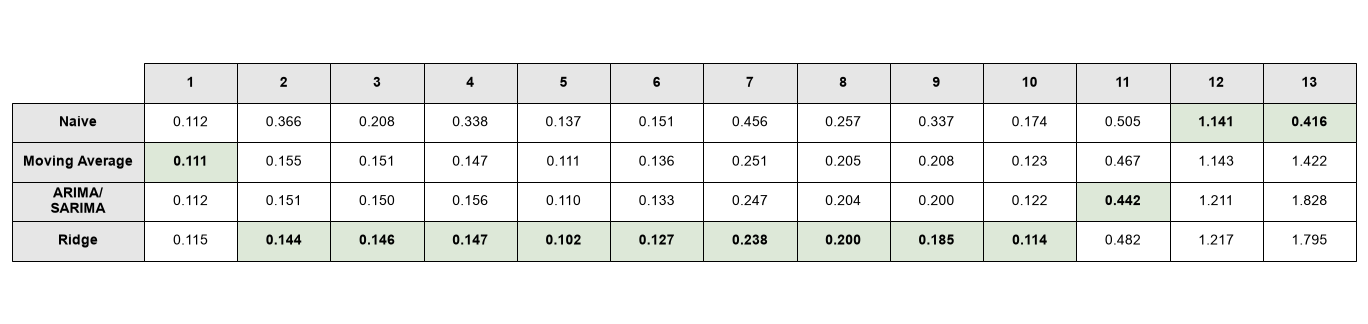

Saved: D:\TU_DataScience\22_Data Mining Cup\TS-Forecasting-Project\outputs\figures\validation_table_h22.png


C:\Users\Sed\AppData\Local\Temp\ipykernel_36208\1385246386.py:51: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  cell_text = table_data.applymap(lambda x: f"{x:.3f}")


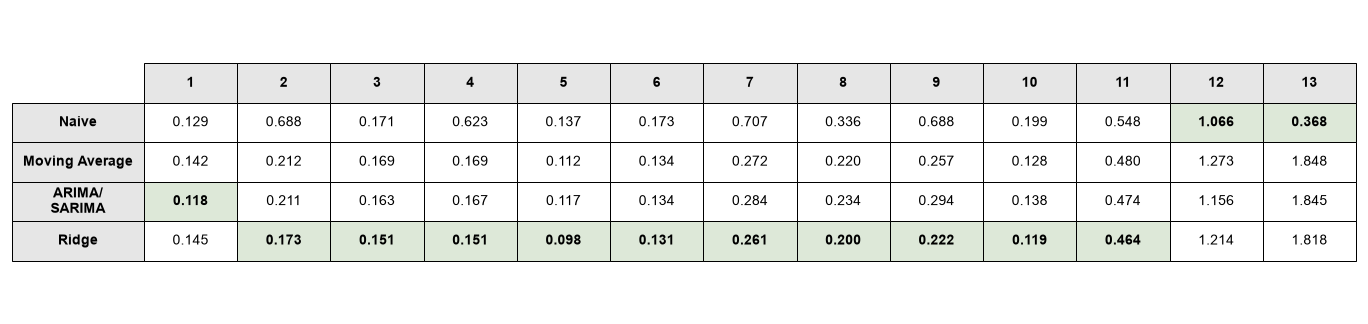

Saved: D:\TU_DataScience\22_Data Mining Cup\TS-Forecasting-Project\outputs\figures\validation_table_h66.png


C:\Users\Sed\AppData\Local\Temp\ipykernel_36208\1385246386.py:51: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  cell_text = table_data.applymap(lambda x: f"{x:.3f}")


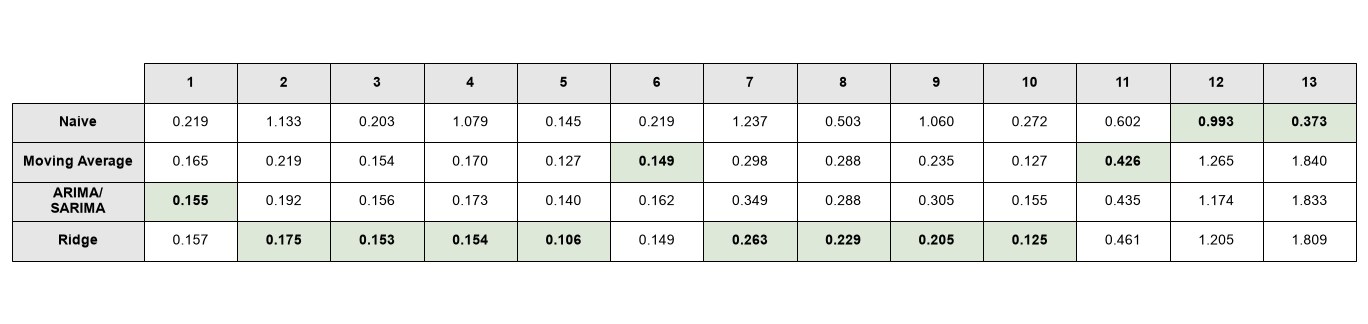

Saved: D:\TU_DataScience\22_Data Mining Cup\TS-Forecasting-Project\outputs\figures\validation_table_h132.png


In [25]:
# ------------------------------------------------------------
# Simple validation table figure for each horizon
# Rows: model families
# Columns: materials
# Cell values: mean validation sMAPE
# Best value in each material column is highlighted
# ------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# If not already defined:
# HORIZONS = [10, 22, 66, 132]
# MATERIALS = list(range(1, 14))
# FAMILY_ORDER = ["Naive", "Moving Average", "ARIMA/SARIMA", "Ridge"]

TABLE_FAMILY_LABELS = {
    "Naive": "Naive",
    "Moving Average": "Moving Average",
    "ARIMA/SARIMA": "ARIMA/\nSARIMA",
    "Ridge": "Ridge"
}

# soft highlight color only for the best value in each column
BEST_CELL_COLOR = "#DDE8D8"   # pale green
HEADER_COLOR = "#E6E6E6"
ROW_LABEL_COLOR = "#E6E6E6"
NORMAL_CELL_COLOR = "white"

def build_validation_table(horizon):
    sub = validation_long.loc[validation_long["horizon"] == horizon].copy()

    table_data = (
        sub.pivot(index="model_family", columns="material", values="mean_smape")
        .reindex(index=FAMILY_ORDER, columns=MATERIALS)
    )

    return table_data


def save_validation_table_csvs():
    for h in HORIZONS:
        table_data = build_validation_table(h)
        table_data.to_csv(TABLE_DIR / f"validation_table_h{h}.csv")


def plot_validation_table(horizon, highlight_best=True):
    table_data = build_validation_table(horizon)

    # formatted strings for display
    cell_text = table_data.applymap(lambda x: f"{x:.3f}")

    # fig, ax = plt.subplots(figsize=(12.5, 2.9))
    fig, ax = plt.subplots(figsize=(11.5, 2.8))
    ax.axis("off")

    tbl = ax.table(
        cellText=cell_text.values,
        rowLabels=[TABLE_FAMILY_LABELS[x] for x in cell_text.index],
        colLabels=[str(c) for c in cell_text.columns],
        cellLoc="center",
        rowLoc="center",
        loc="center"
    )

    tbl.auto_set_font_size(False)
    # tbl.set_fontsize(9)
    # tbl.scale(1.0, 1.85)


    tbl.set_fontsize(8.5)
    tbl.scale(1.0, 1.7)

    # base styling
    for (row, col), cell in tbl.get_celld().items():
        cell.set_edgecolor("black")
        cell.set_linewidth(0.6)

        # column headers
        if row == 0:
            cell.set_facecolor(HEADER_COLOR)
            cell.set_text_props(weight="bold", color="black")

        # row labels
        if col == -1 and row > 0:
            cell.set_facecolor(ROW_LABEL_COLOR)
            cell.set_text_props(weight="bold", color="black")

        # normal data cells
        if row > 0 and col >= 0:
            cell.set_facecolor(NORMAL_CELL_COLOR)
            cell.set_text_props(color="black", weight="normal")

    # highlight best family per material
    if highlight_best:
        for j, material in enumerate(table_data.columns):
            best_value = table_data[material].min()

            for i, family in enumerate(table_data.index, start=1):
                val = table_data.loc[family, material]
                if np.isclose(val, best_value, atol=1e-12):
                    cell = tbl[(i, j)]
                    cell.set_facecolor(BEST_CELL_COLOR)
                    cell.set_text_props(weight="bold", color="black")

    # ax.set_title(
    #     f"Validation comparison by model family for horizon {horizon}",
    #     fontsize=12,
    #     pad=12
    # )

    # small note under table
    # ax.text(
    #     0.5, -0.08,
    #     "Each cell shows mean validation sMAPE. Highlighted cells indicate the best-performing model family for each material.",
    #     ha="center",
    #     va="top",
    #     fontsize=9,
    #     transform=ax.transAxes
    # )

    fig.tight_layout()
    output = FIGURE_DIR / f"validation_table_h{horizon}.png"
    fig.savefig(output, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", output)


# Save CSVs
save_validation_table_csvs()

# Create one table figure for each horizon
for h in HORIZONS:
    plot_validation_table(horizon=h, highlight_best=True)

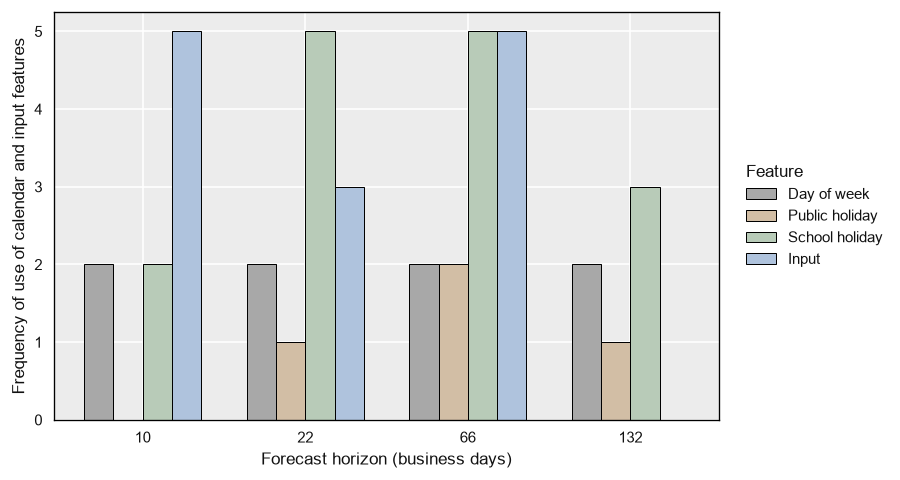

Saved: D:\TU_DataScience\22_Data Mining Cup\TS-Forecasting-Project\outputs\figures\ridge_selected_feature_counts_clean.png


In [30]:
# ------------------------------------------------------------
# Ridge selected feature usage - cleaner version
# ------------------------------------------------------------
ridge = frozen.loc[frozen["model_family"] == "Ridge"].copy()

ridge["uses_input"] = (
    ridge["input_lags"].fillna("").astype(str).str.strip().ne("") |
    ridge["input_rolling"].fillna("").astype(str).str.strip().ne("")
).astype(int)

feature_counts = (
    ridge.groupby("horizon", as_index=False)
    .agg(
        n_selected_ridge=("material", "size"),
        day_of_week=("use_day_of_week", "sum"),
        public_holiday=("use_public_holiday", "sum"),
        school_holiday=("use_school_holiday", "sum"),
        input_features=("uses_input", "sum"),
    )
)

for col in [
    "n_selected_ridge",
    "day_of_week",
    "public_holiday",
    "school_holiday",
    "input_features",
]:
    feature_counts[col] = feature_counts[col].astype(int)

feature_counts.to_csv(
    TABLE_DIR / "ridge_feature_selection_counts.csv",
    index=False
)

feature_labels = {
    "day_of_week": "Day of week",
    "public_holiday": "Public holiday",
    "school_holiday": "School holiday",
    "input_features": "Input",
}

# muted/pastel colors
feature_colors = {
    "day_of_week": "#A8A8A8",
    "public_holiday": "#D2BEA5",
    "school_holiday": "#B8CBB8",
    "input_features": "#AFC3DD",
}

fig, ax = plt.subplots(figsize=(7.6, 4.1))

x = np.arange(len(HORIZONS))
width = 0.18
offsets = np.array([-1.5, -0.5, 0.5, 1.5]) * width

for offset, feature in zip(offsets, feature_labels):
    ax.bar(
        x + offset,
        feature_counts.set_index("horizon").loc[HORIZONS, feature].values,
        width=width,
        label=feature_labels[feature],
        color=feature_colors[feature],
        edgecolor="black",
        linewidth=0.6,
    )

ax.set_xticks(x)
ax.set_xticklabels(HORIZONS)
ax.set_xlabel("Forecast horizon (business days)")
ax.set_ylabel("Frequency of use of calendar and input features")
# ax.set_title("Use of calendar and Input features in selected Ridge models")

ax.set_facecolor("#ECECEC")
fig.patch.set_facecolor("white")
ax.grid(True, axis="y", color="white", linewidth=1.0)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(0.8)

legend = ax.legend(
    frameon=False,
    title="Feature",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    ncol=1
)
legend.get_title().set_ha("left")
legend._legend_box.align = "left"

plt.subplots_adjust(right=0.80)
fig.tight_layout()

output = FIGURE_DIR / "ridge_selected_feature_counts_clean.png"
fig.savefig(output, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", output)

Saved: D:\TU_DataScience\22_Data Mining Cup\TS-Forecasting-Project\outputs\figures\actual_vs_forecast_material_1.png


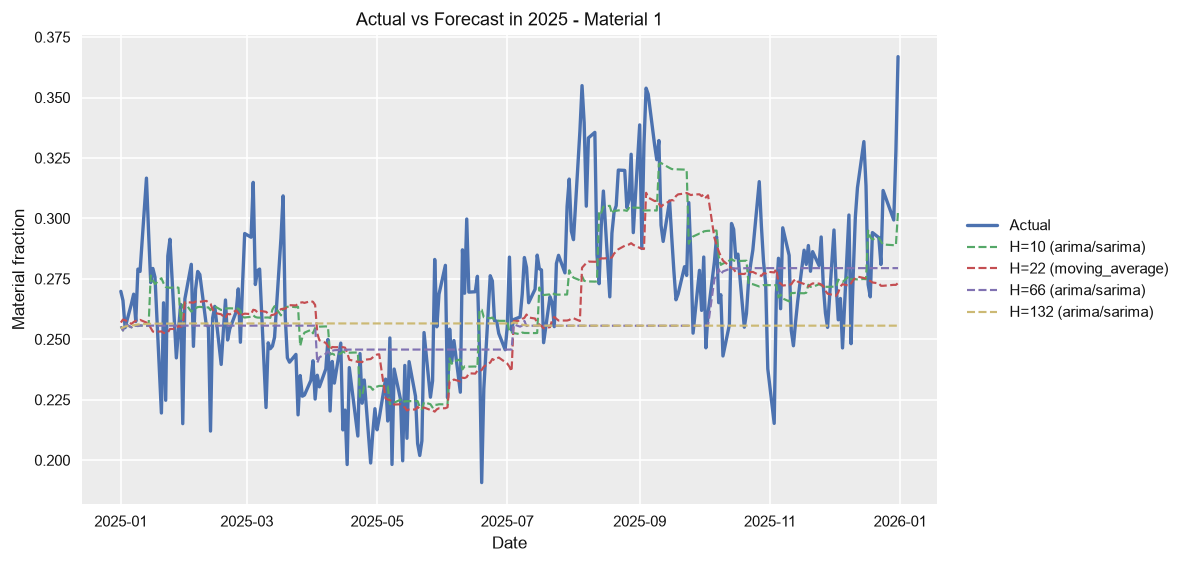

Saved: D:\TU_DataScience\22_Data Mining Cup\TS-Forecasting-Project\outputs\figures\actual_vs_forecast_material_2.png


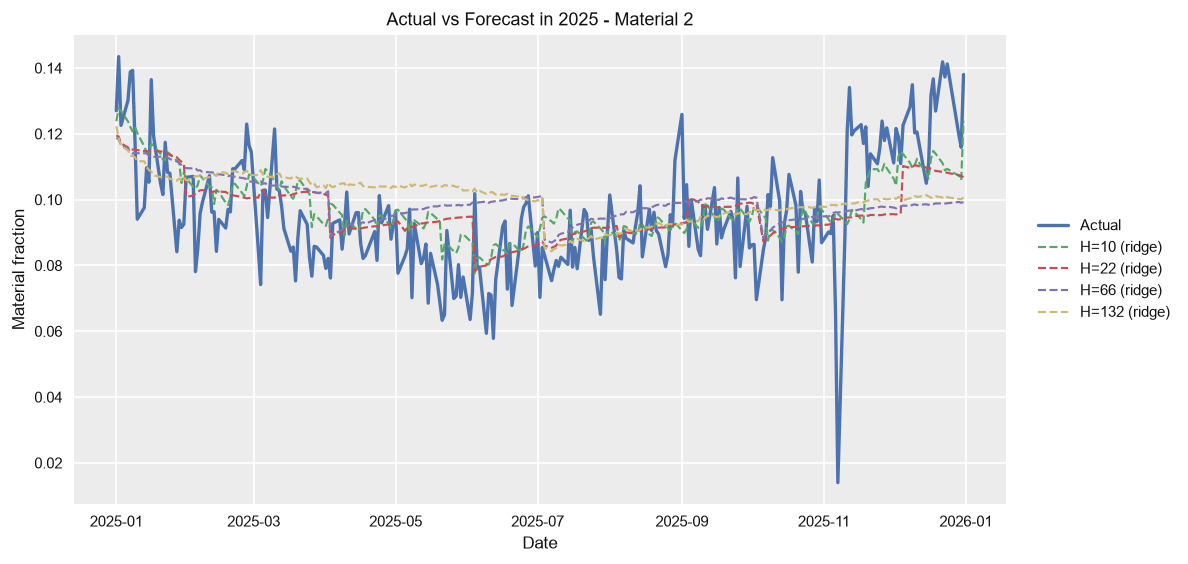

Saved: D:\TU_DataScience\22_Data Mining Cup\TS-Forecasting-Project\outputs\figures\actual_vs_forecast_material_3.png


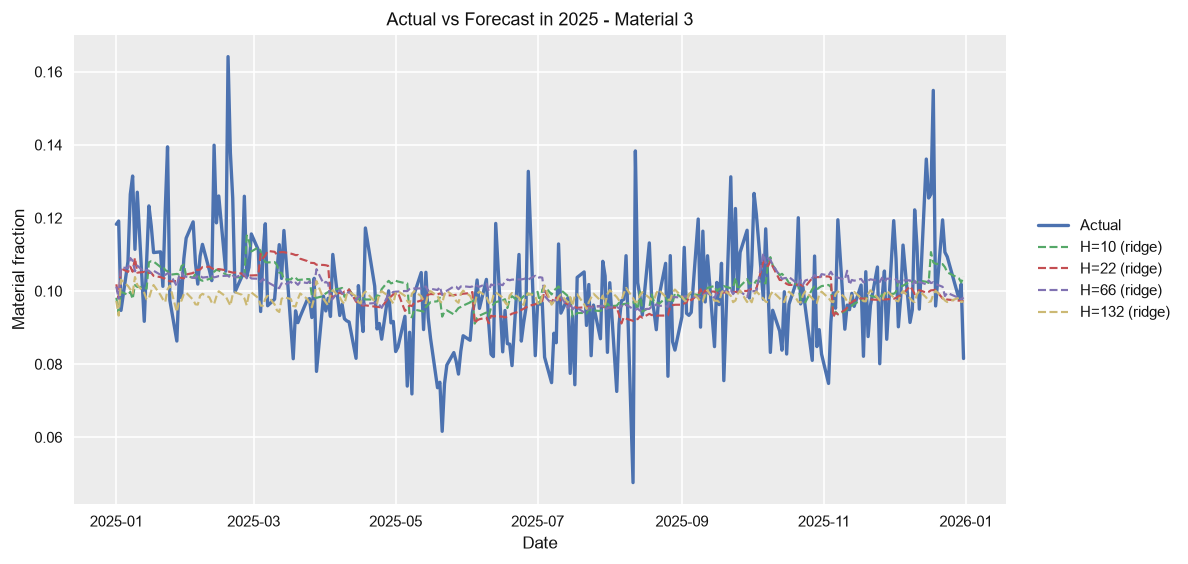

Saved: D:\TU_DataScience\22_Data Mining Cup\TS-Forecasting-Project\outputs\figures\actual_vs_forecast_material_4.png


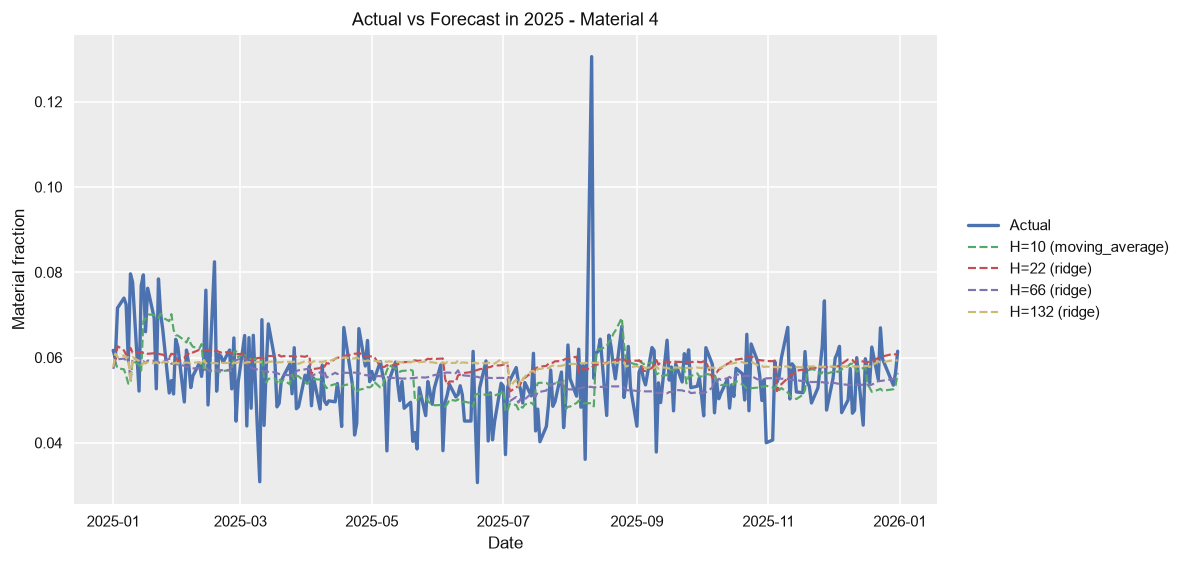

Saved: D:\TU_DataScience\22_Data Mining Cup\TS-Forecasting-Project\outputs\figures\actual_vs_forecast_material_5.png


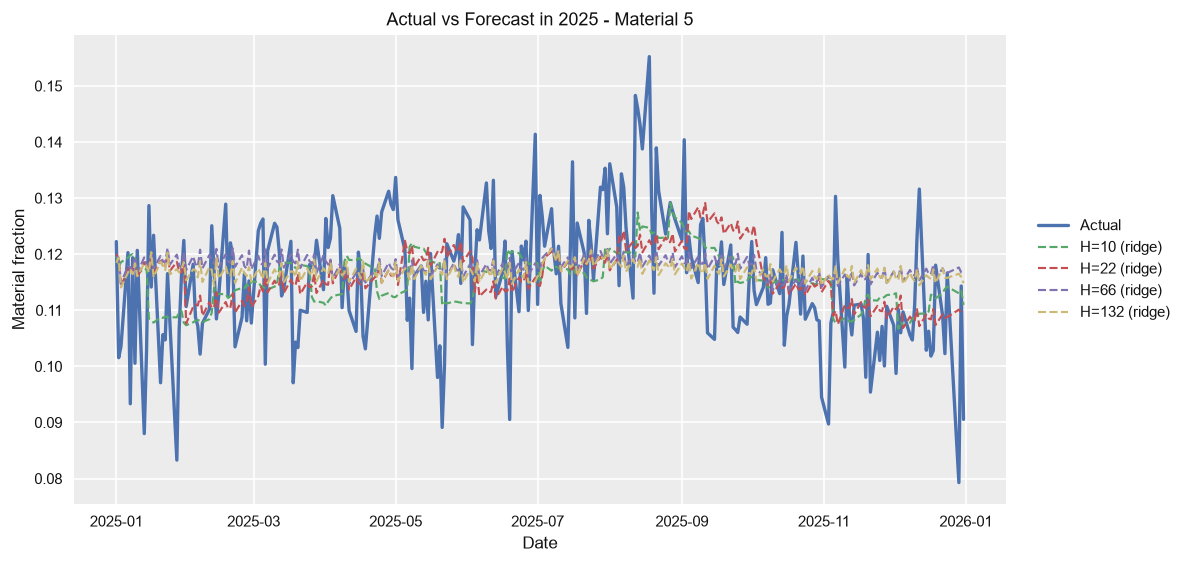

Saved: D:\TU_DataScience\22_Data Mining Cup\TS-Forecasting-Project\outputs\figures\actual_vs_forecast_material_6.png


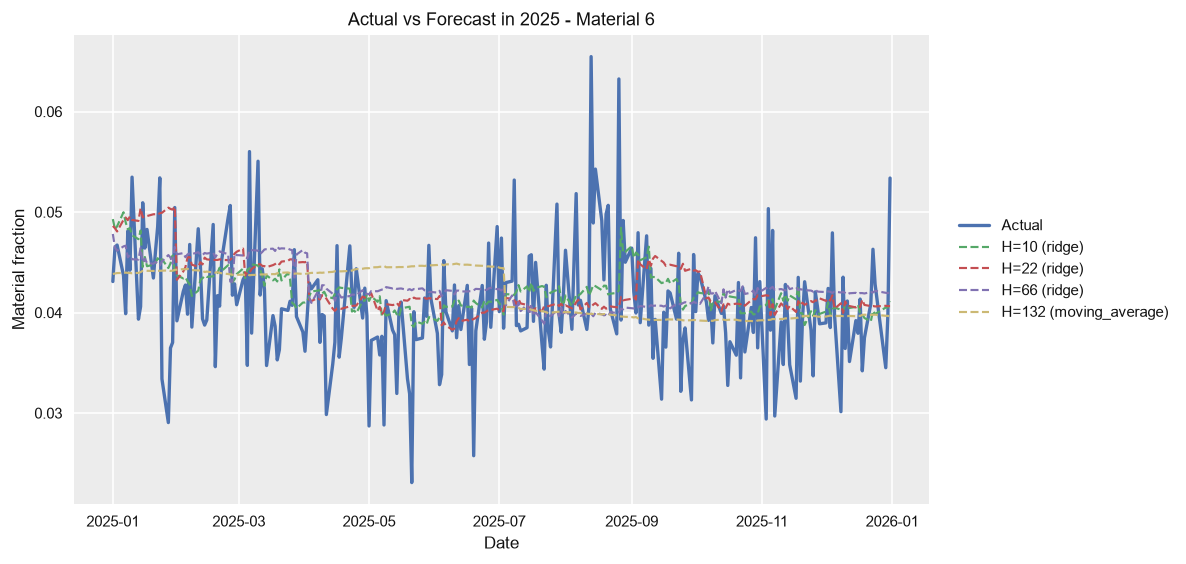

Saved: D:\TU_DataScience\22_Data Mining Cup\TS-Forecasting-Project\outputs\figures\actual_vs_forecast_material_7.png


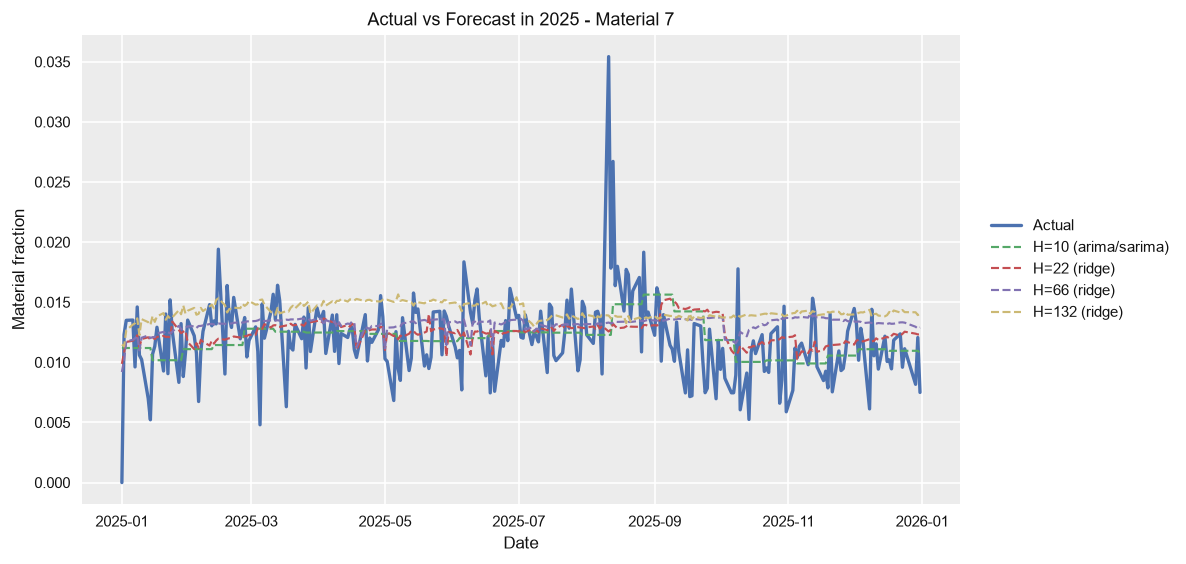

Saved: D:\TU_DataScience\22_Data Mining Cup\TS-Forecasting-Project\outputs\figures\actual_vs_forecast_material_8.png


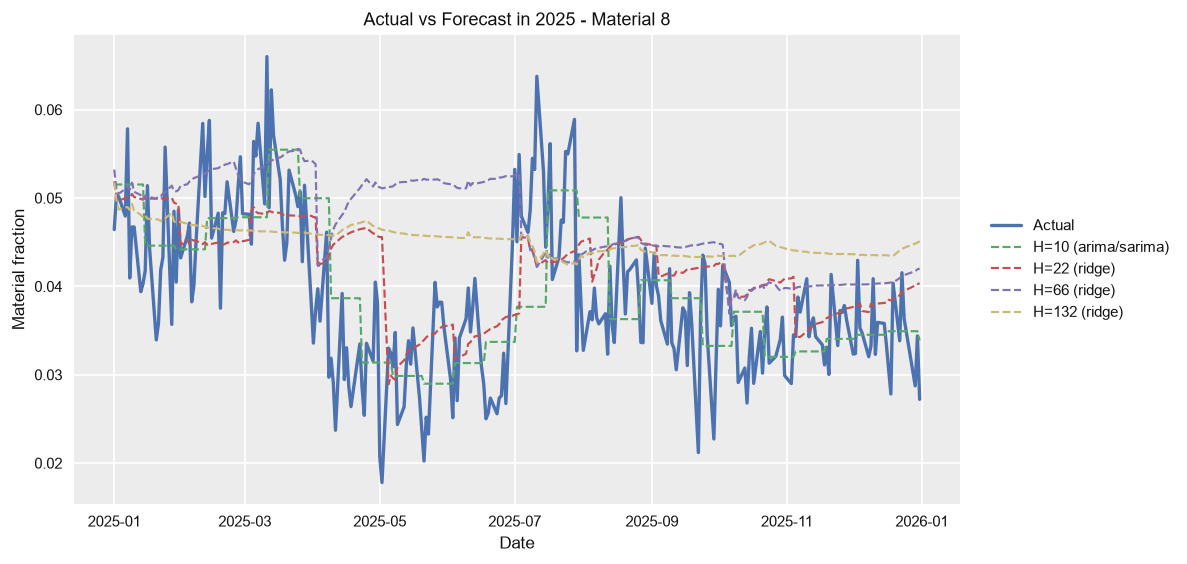

Saved: D:\TU_DataScience\22_Data Mining Cup\TS-Forecasting-Project\outputs\figures\actual_vs_forecast_material_9.png


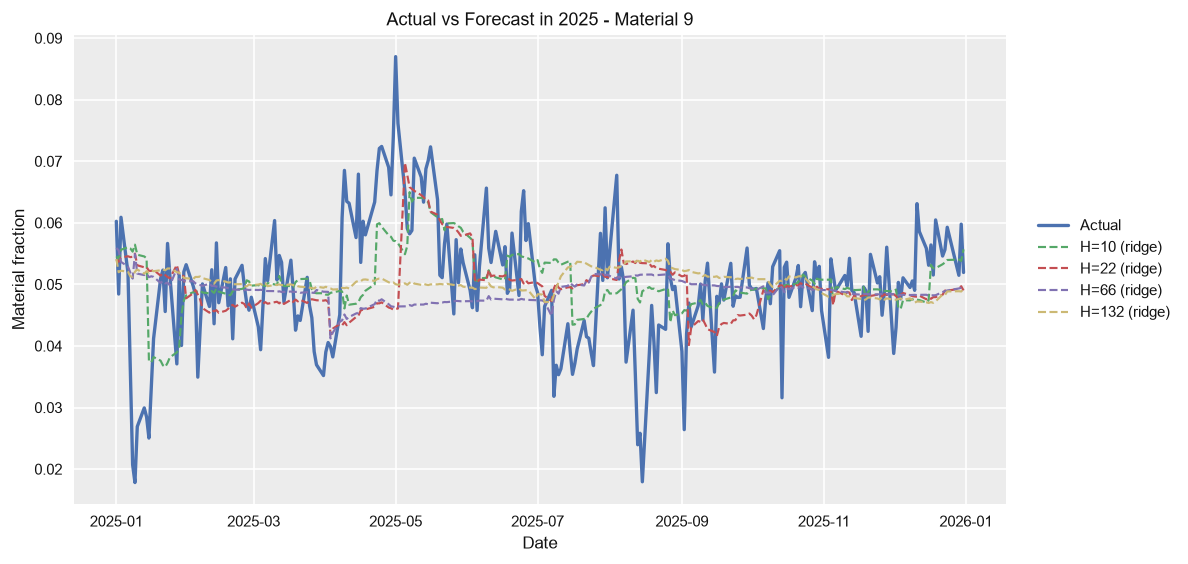

Saved: D:\TU_DataScience\22_Data Mining Cup\TS-Forecasting-Project\outputs\figures\actual_vs_forecast_material_10.png


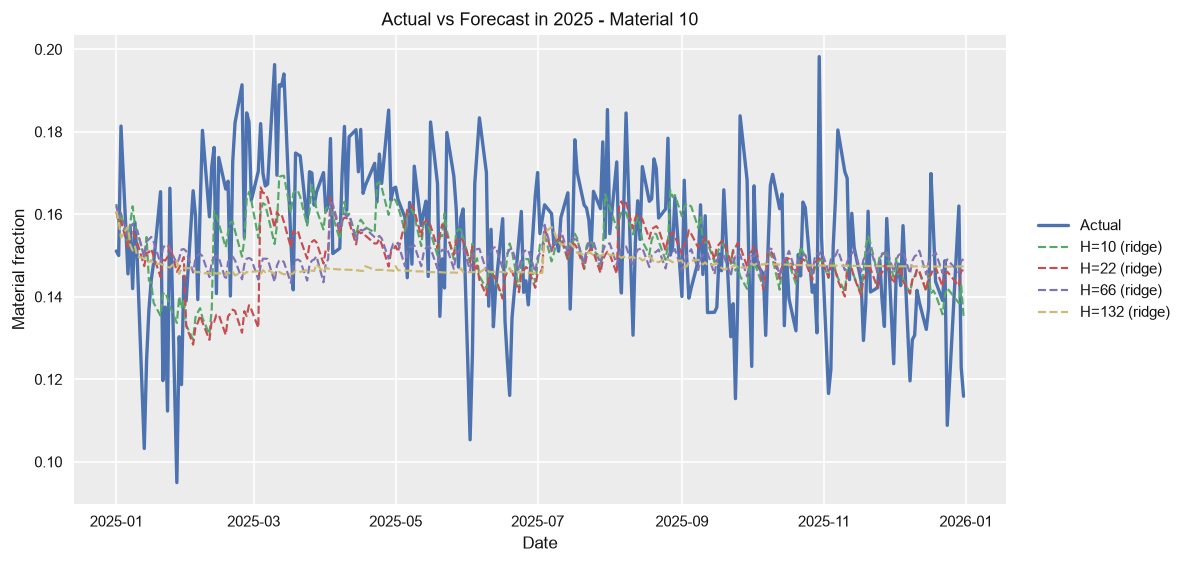

Saved: D:\TU_DataScience\22_Data Mining Cup\TS-Forecasting-Project\outputs\figures\actual_vs_forecast_material_11.png


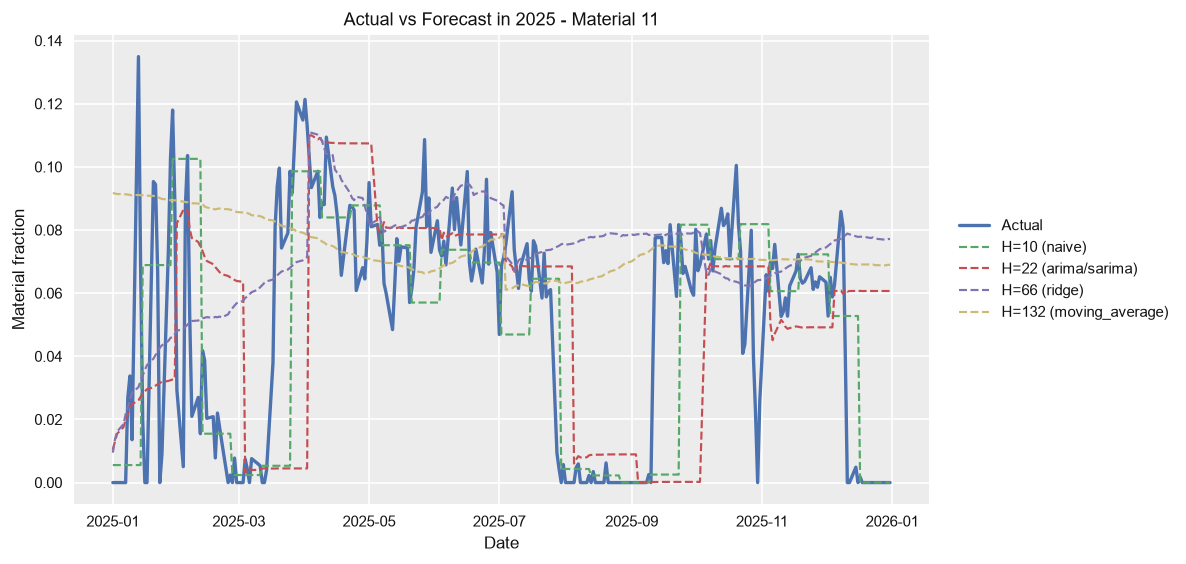

Saved: D:\TU_DataScience\22_Data Mining Cup\TS-Forecasting-Project\outputs\figures\actual_vs_forecast_material_12.png


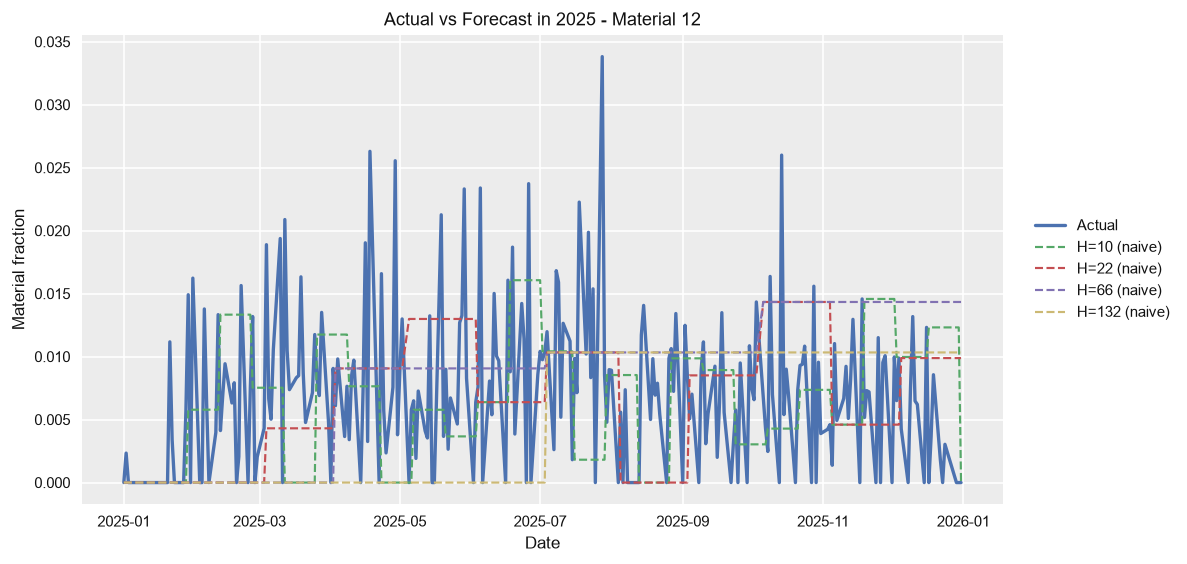

Saved: D:\TU_DataScience\22_Data Mining Cup\TS-Forecasting-Project\outputs\figures\actual_vs_forecast_material_13.png


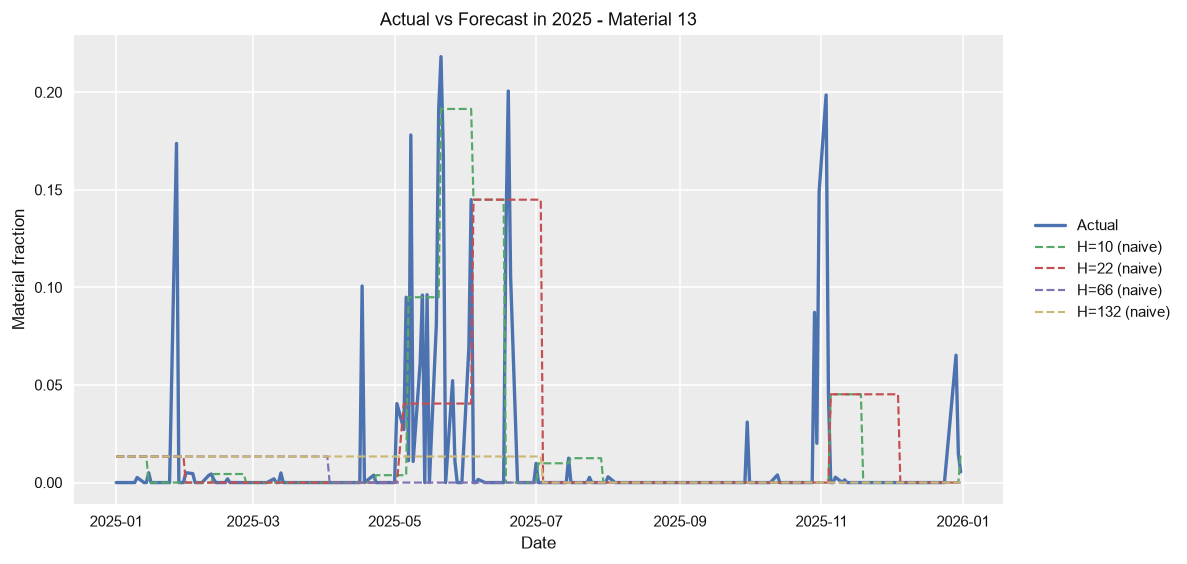

In [34]:
# ------------------------------------------------------------
# Actual vs Forecast for all materials
# ------------------------------------------------------------
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import math

# -------- paths --------
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

FORECAST_PATH = PROJECT_ROOT / "outputs" / "forecasts" / "forecasts.csv"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# -------- load data --------
df = pd.read_csv(FORECAST_PATH, parse_dates=["Date"])

# فقط نقاطی که actual دارند
if "is_observed" in df.columns:
    df = df[df["is_observed"] == True].copy()

# مرتب‌سازی
df = df.sort_values(["material", "Date", "horizon"]).copy()

# horizon order
HORIZONS = [10, 22, 66, 132]

# -------- plotting function for one material --------
def plot_one_material(material_id, save=True):
    sub = df[df["material"] == material_id].copy()

    if sub.empty:
        print(f"No data for Material {material_id}")
        return

    # actual values (one per date)
    actual = (
        sub[["Date", "actual"]]
        .drop_duplicates(subset=["Date"])
        .sort_values("Date")
    )

    fig, ax = plt.subplots(figsize=(10, 4.8))

    # actual
    ax.plot(
        actual["Date"],
        actual["actual"],
        linewidth=2.0,
        label="Actual"
    )

    # forecasts for each horizon
    for h in HORIZONS:
        hsub = (
            sub[sub["horizon"] == h][["Date", "forecast", "model"]]
            .sort_values("Date")
            .copy()
        )

        if hsub.empty:
            continue

        model_name = hsub["model"].iloc[0]
        ax.plot(
            hsub["Date"],
            hsub["forecast"],
            linewidth=1.3,
            linestyle="--",
            label=f"H={h} ({model_name})"
        )

    ax.set_title(f"Actual vs Forecast in 2025 - Material {material_id}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Material fraction")
    ax.grid(True, axis="both")
    ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5))

    fig.tight_layout()

    if save:
        out_path = FIGURE_DIR / f"actual_vs_forecast_material_{material_id}.png"
        fig.savefig(out_path, dpi=300, bbox_inches="tight")
        print("Saved:", out_path)

    plt.show()


# -------- plot all materials one by one --------
for m in sorted(df["material"].unique()):
    plot_one_material(m)

[np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13)]
Saved: D:\TU_DataScience\22_Data Mining Cup\TS-Forecasting-Project\outputs\figures\actual_vs_forecast_all_materials_panel.png


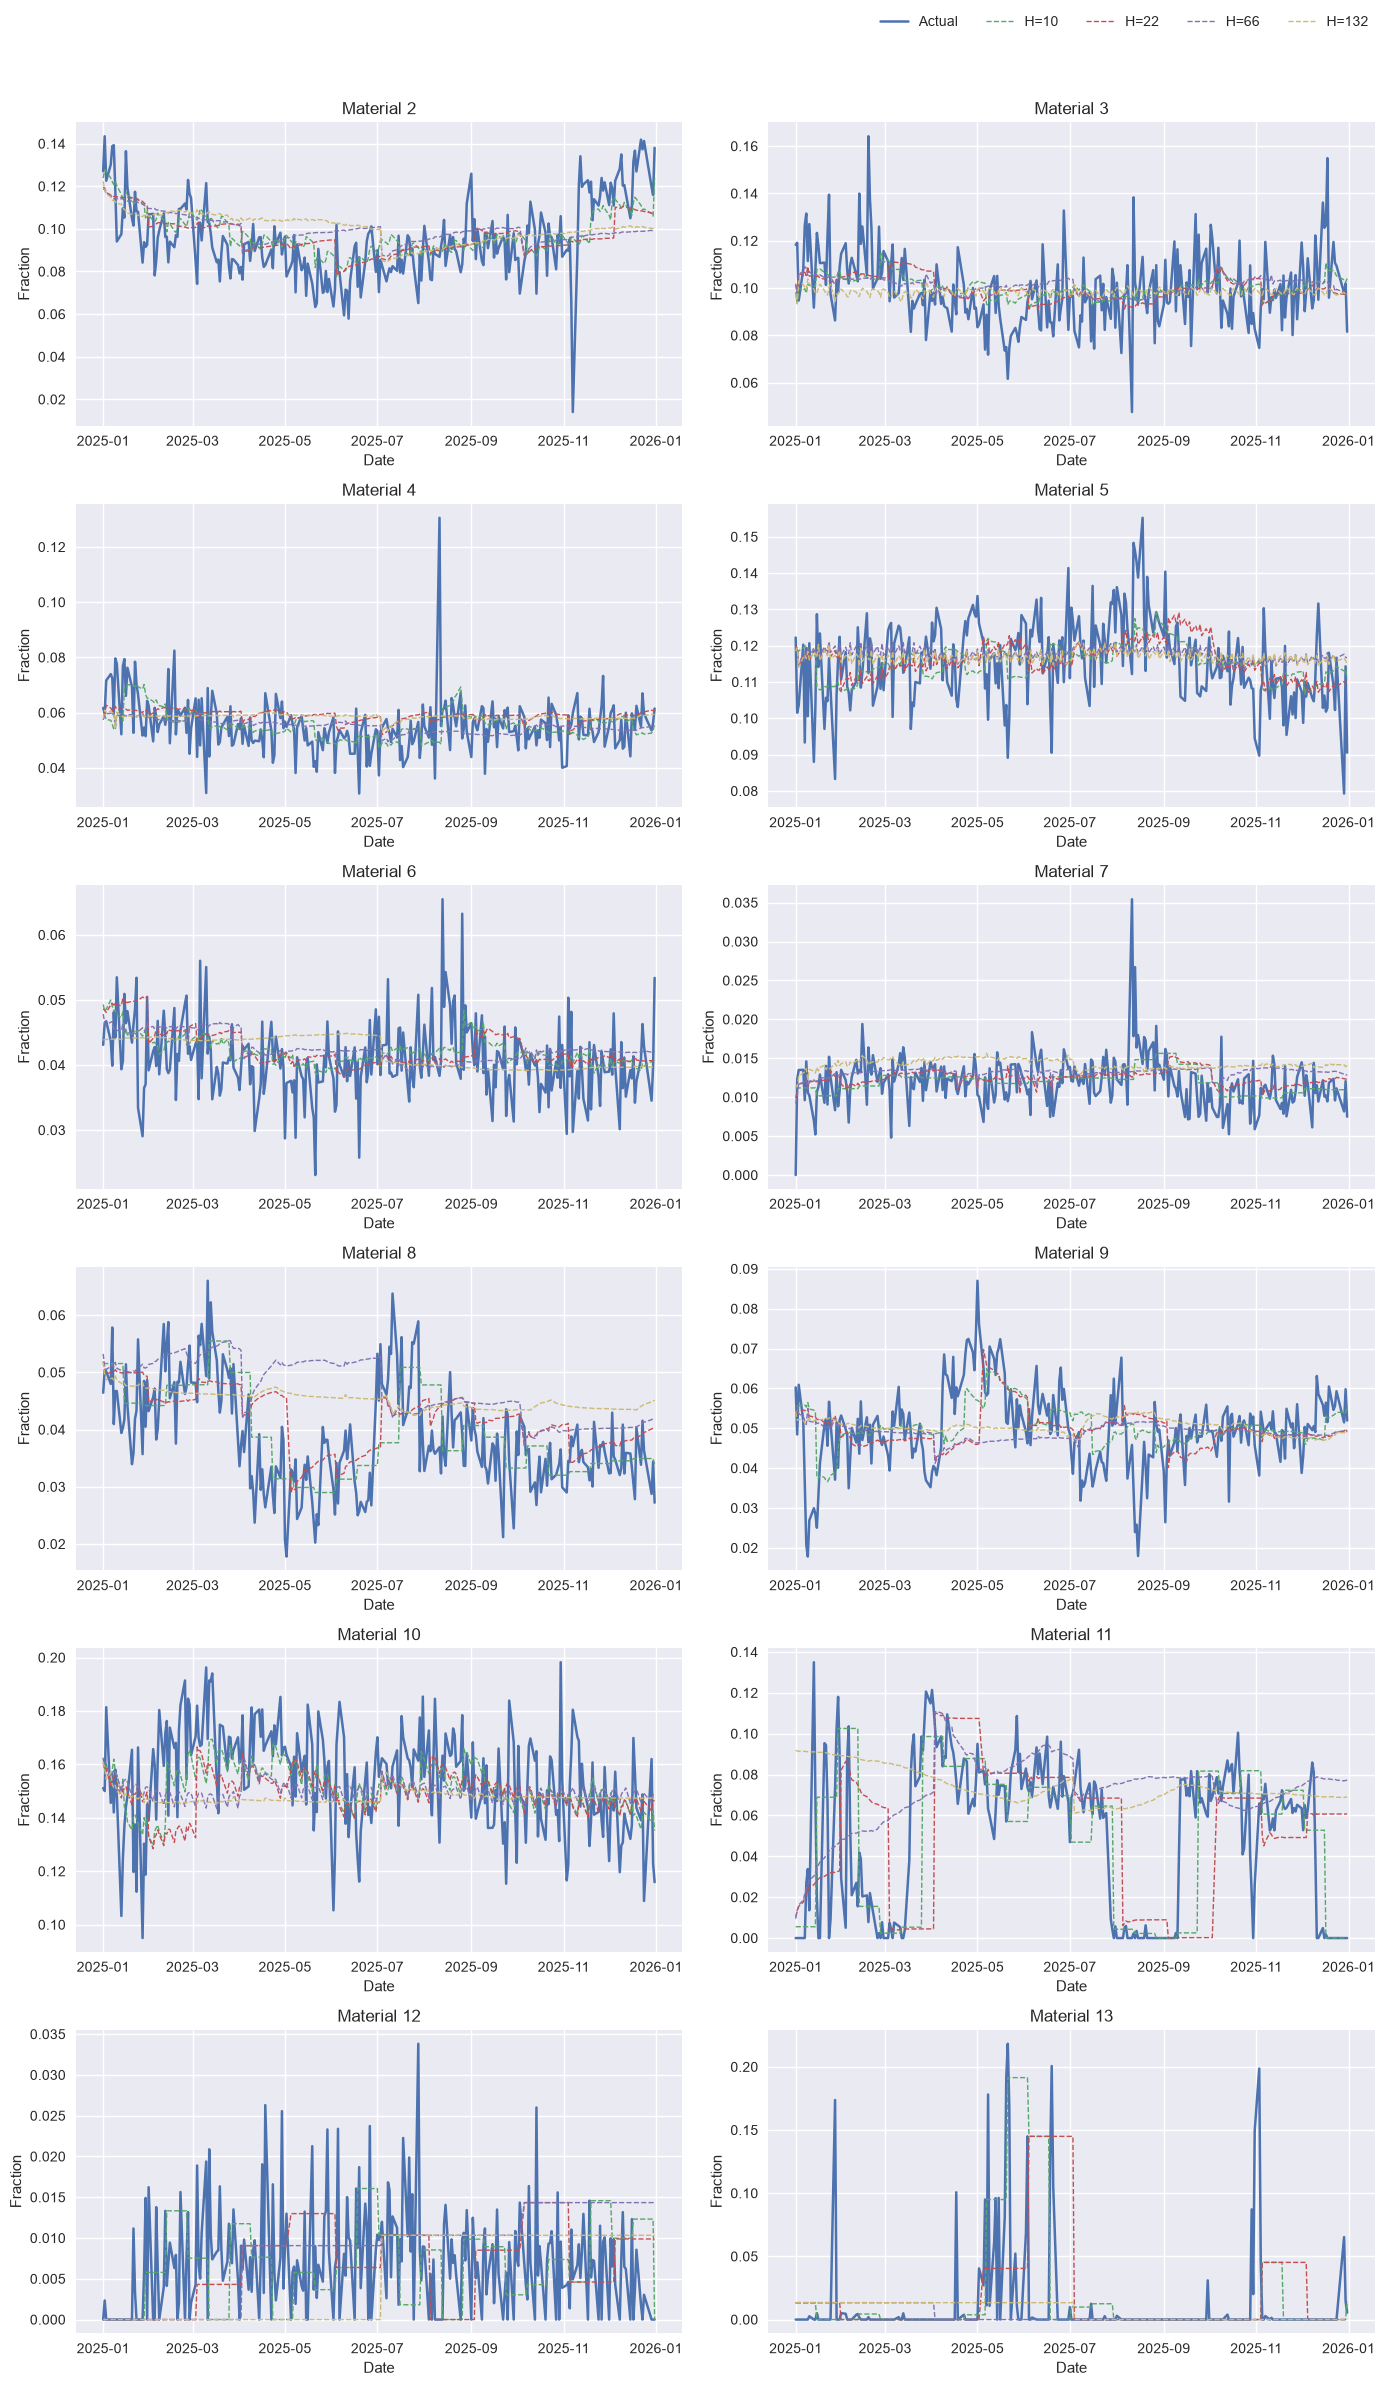

In [39]:
# ------------------------------------------------------------
# Multi-panel figure for all materials
# ------------------------------------------------------------
materials = sorted(df.loc[df["material"] != 1, "material"].unique())
print(materials)
n = len(materials)

ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows), sharex=False)
axes = axes.flatten()

for ax, material_id in zip(axes, materials):
    sub = df[df["material"] == material_id].copy()

    actual = (
        sub[["Date", "actual"]]
        .drop_duplicates(subset=["Date"])
        .sort_values("Date")
    )

    ax.plot(
        actual["Date"],
        actual["actual"],
        linewidth=1.8,
        label="Actual"
    )

    for h in HORIZONS:
        hsub = (
            sub[sub["horizon"] == h][["Date", "forecast", "model"]]
            .sort_values("Date")
            .copy()
        )

        if hsub.empty:
            continue

        model_name = hsub["model"].iloc[0]
        ax.plot(
            hsub["Date"],
            hsub["forecast"],
            linewidth=1.0,
            linestyle="--",
            label=f"H={h}"
        )

    ax.set_title(f"Material {material_id}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Fraction")
    ax.grid(True)

# hide empty axes if any
for i in range(len(materials), len(axes)):
    axes[i].axis("off")

# one common legend
handles, labels = axes[0].get_legend_handles_labels()

# title on the upper-lef

# legend on the upper-right
fig.legend(
    handles,
    labels,
    frameon=False,
    loc="upper right",
    bbox_to_anchor=(0.99, 0.995),
    ncol=5
)

# reserve space above the subplots
fig.tight_layout(rect=[0, 0, 1, 0.96])

out_path = FIGURE_DIR / "actual_vs_forecast_all_materials_panel.png"
fig.savefig(
    out_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.15
)

print("Saved:", out_path)
plt.show()